In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("C:/Users/bayra/OneDrive/Masaüstü/results.csv")

In [41]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [42]:
import matplotlib.font_manager as fm

def set_football_style():
    plt.style.use("dark_background")

    plt.rcParams['figure.facecolor'] = '#0e1117'
    plt.rcParams['axes.facecolor']   = '#0e1117'
    plt.rcParams['savefig.facecolor'] = '#0e1117'

    plt.rcParams['font.family'] = 'DejaVu Sans' 
    plt.rcParams['font.weight'] = 'medium'

    plt.rcParams['axes.labelcolor'] = '#E5E5E5'
    plt.rcParams['axes.edgecolor'] = '#E5E5E5'
    plt.rcParams['text.color'] = '#E5E5E5'
    plt.rcParams['xtick.color'] = '#B0B0B0'
    plt.rcParams['ytick.color'] = '#B0B0B0'

    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.color'] = '#222831'
    plt.rcParams['grid.alpha'] = 0.6
    plt.rcParams['grid.linestyle'] = '--'
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.right'] = False

    plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[
        '#00B4D8',  
        '#FFD60A',  
        '#E63946', 
        '#90E0EF', 
        '#9B5DE5',  
        '#06D6A0',  
    ])

    plt.rcParams['figure.figsize'] = (10, 5)
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10

    plt.rcParams['lines.antialiased'] = True

    print("✅ Football-style Matplotlib theme activated!")

set_football_style()

✅ Football-style Matplotlib theme activated!


In [43]:
df['tournament'].value_counts().head(20)

tournament
Friendly                                18116
FIFA World Cup qualification             8529
UEFA Euro qualification                  2824
African Cup of Nations qualification     2278
FIFA World Cup                            964
Copa América                              869
AFC Asian Cup qualification               794
African Cup of Nations                    793
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
Gulf Cup                                  410
Island Games                              394
UEFA Euro                                 388
Asian Games                               368
Name: count, dtype: int64

In [44]:
df['date'] = pd.to_datetime(df['date'])

In [45]:
df['year'] = df['date'].dt.year

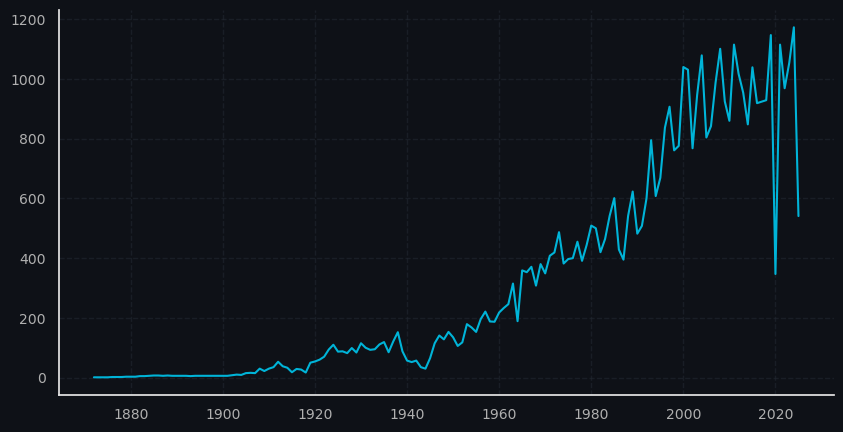

In [46]:
plt.plot(df.groupby('year').size())

<Axes: xlabel='year'>

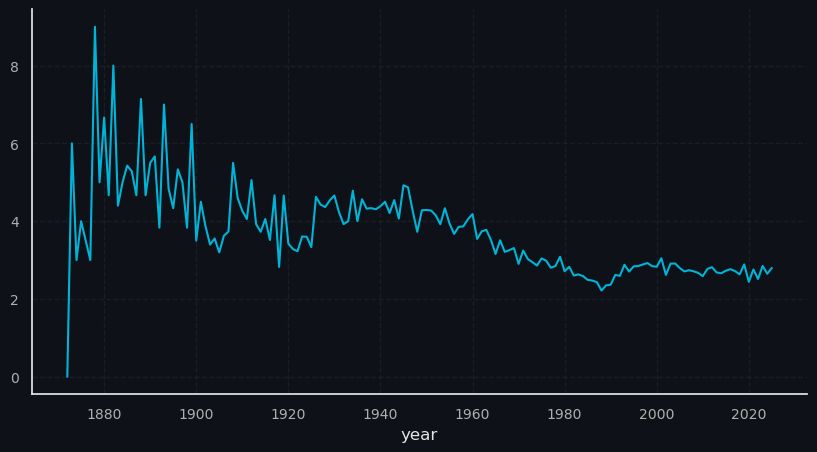

In [47]:
df.groupby('year')[['home_score','away_score']].mean().sum(axis=1).plot()

In [48]:
home_win_rate = (df['home_score'] > df['away_score']).mean()

In [50]:
df.groupby('tournament')[['home_score','away_score']].mean().sum(axis=1).sort_values(ascending=False).head(10)

tournament
East Asian Games                           7.235294
Inter-Allied Games                         6.692308
Benedikt Fontana Cup                       6.000000
Atlantic Heritage Cup                      6.000000
Évence Coppée Trophy                       6.000000
South Pacific Games                        5.912195
Tynwald Hill Tournament                    5.833333
GaNEFo                                     5.785714
CONIFA World Football Cup qualification    5.600000
Central American and Caribbean Games       5.587302
dtype: float64

In [51]:
pd.concat([df['home_team'], df['away_team']]).value_counts().head(10)

Sweden         1093
England        1082
Argentina      1059
Brazil         1051
Germany        1023
South Korea     999
Hungary         998
Mexico          992
Uruguay         960
France          927
Name: count, dtype: int64

In [52]:
df['year'] = df['date'].dt.year
df['decade'] = (df['year'] // 10) * 10

df['total_goals'] = df['home_score'] + df['away_score']

df['result'] = np.where(
    df['home_score'] > df['away_score'], 'Home Win',
    np.where(df['home_score'] < df['away_score'], 'Away Win', 'Draw')
)

df['is_home_win'] = df['result'] == 'Home Win'
df['is_away_win'] = df['result'] == 'Away Win'
df['is_draw'] = df['result'] == 'Draw'

In [53]:
major_tournaments = [
    'FIFA World Cup', 'UEFA Euro', 'Copa América',
    'AFC Asian Cup', 'Africa Cup of Nations',
    'Gold Cup', 'Confederations Cup', 'OFC Nations Cup'
]

df['is_major_tournament'] = df['tournament'].isin(major_tournaments)

In [55]:
df.isnull().sum()

date                   0
home_team              0
away_team              0
home_score             0
away_score             0
tournament             0
city                   0
country                0
neutral                0
year                   0
decade                 0
total_goals            0
result                 0
is_home_win            0
is_away_win            0
is_draw                0
is_major_tournament    0
dtype: int64

In [56]:
print("Shape of dataset:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nDescriptive statistics:")
display(df[['home_score', 'away_score', 'total_goals']].describe())

print("\nUnique home teams:", df['home_team'].nunique())
print("Unique tournaments:", df['tournament'].nunique())
print("Date range:", df['date'].min(), "→", df['date'].max())

Shape of dataset: (48532, 17)

Data types:
date                   datetime64[ns]
home_team                      object
away_team                      object
home_score                      int64
away_score                      int64
tournament                     object
city                           object
country                        object
neutral                          bool
year                            int32
decade                          int32
total_goals                     int64
result                         object
is_home_win                      bool
is_away_win                      bool
is_draw                          bool
is_major_tournament              bool
dtype: object

Descriptive statistics:


,home_score,away_score,total_goals
count,48532.000000,48532.000000,48532.000000
mean,1.758180,1.181550,2.939730
std,1.773101,1.400946,2.095142
min,0.000000,0.000000,0.000000
25%,1.000000,0.000000,1.000000
50%,1.000000,1.000000,3.000000
75%,2.000000,2.000000,4.000000
max,31.000000,21.000000,31.000000



Unique home teams: 325
Unique tournaments: 188
Date range: 1872-11-30 00:00:00 → 2025-09-09 00:00:00


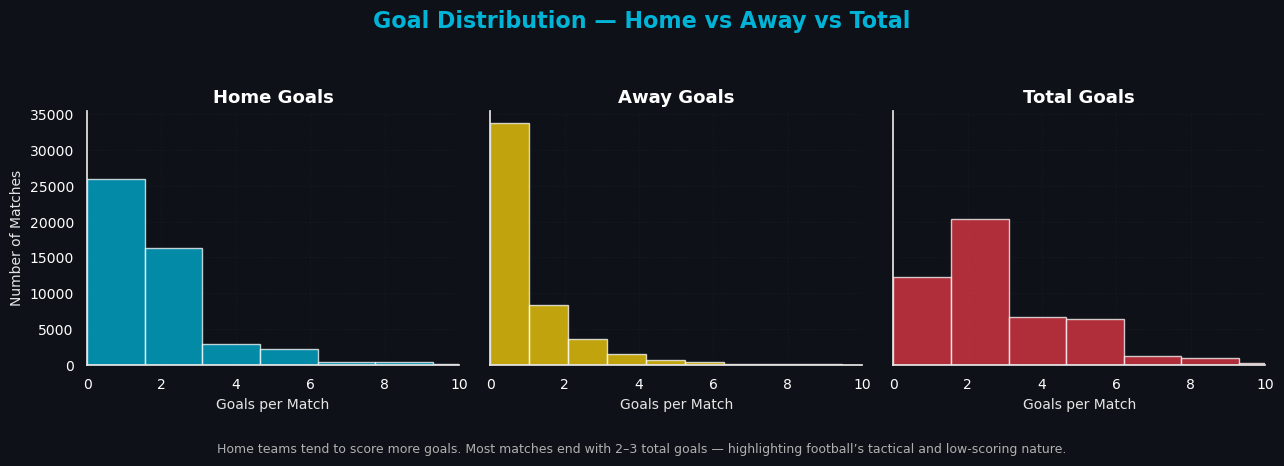

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(13,4), sharey=True, sharex=True)

axes[0].hist(df['home_score'], bins=20, color='#00B4D8', alpha=0.75)
axes[0].set_title('Home Goals', color='white', fontsize=13, weight='bold')

axes[1].hist(df['away_score'], bins=20, color='#FFD60A', alpha=0.75)
axes[1].set_title('Away Goals', color='white', fontsize=13, weight='bold')

axes[2].hist(df['total_goals'], bins=20, color='#E63946', alpha=0.75)
axes[2].set_title('Total Goals', color='white', fontsize=13, weight='bold')

for ax in axes:
    ax.set_facecolor('#0e1117')
    ax.grid(alpha=0.3, linestyle='--', linewidth=0.6)
    ax.tick_params(colors='white')
    ax.set_xlim(0, 10)
    ax.set_xlabel('Goals per Match', fontsize=10)
axes[0].set_ylabel('Number of Matches', fontsize=10)

fig.suptitle("Goal Distribution — Home vs Away vs Total",
             fontsize=16, color='#00B4D8', weight='bold', y=1.05)

fig.text(0.5, -0.05,
         "Home teams tend to score more goals. Most matches end with 2–3 total goals — "
         "highlighting football’s tactical and low-scoring nature.",
         ha='center', va='center', color='#B0B0B0', fontsize=9)

plt.tight_layout()
plt.show()

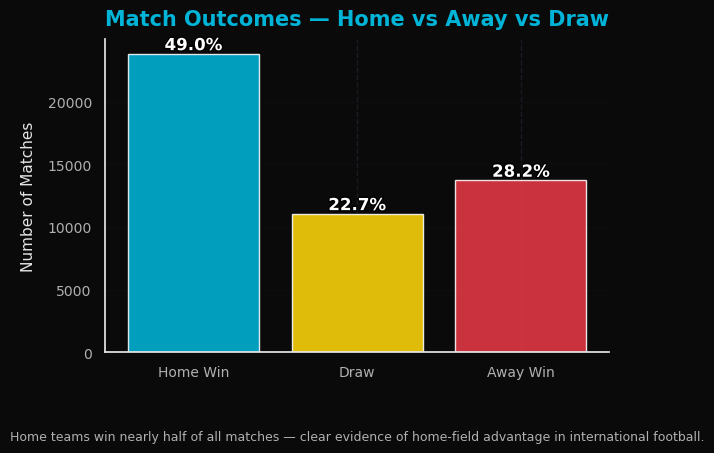

In [58]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as mpl
import pandas as pd

home_wins = (df['home_score'] > df['away_score']).sum()
away_wins = (df['home_score'] < df['away_score']).sum()
draws = (df['home_score'] == df['away_score']).sum()

outcomes = pd.DataFrame({
    'Outcome': ['Home Win', 'Draw', 'Away Win'],
    'Count': [home_wins, draws, away_wins]
})
outcomes['Percentage'] = outcomes['Count'] / outcomes['Count'].sum() * 100

colors = ['#00B4D8', '#FFD60A', '#E63946']
background = '#0A0A0A' 

fig, ax = plt.subplots(figsize=(7, 5), facecolor=background)
ax.set_facecolor(background)

bars = ax.bar(outcomes['Outcome'], outcomes['Count'], color=colors, alpha=0.88)

for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 300,
            f"{outcomes['Percentage'][i]:.1f}%",
            ha='center', fontsize=12, color='white', fontweight='bold',
            path_effects=[mpl.withStroke(linewidth=2, foreground='black')])

ax.set_title("Match Outcomes — Home vs Away vs Draw",
             fontsize=15, weight='bold', color='#00B4D8', pad=10)
ax.set_ylabel("Number of Matches", fontsize=11, labelpad=8)
ax.grid(axis='y', alpha=0.25, linestyle='--', linewidth=0.5)

ax.text(1, -7000,
        "Home teams win nearly half of all matches — clear evidence of home-field advantage in international football.",
        ha='center', color='#B0B0B0', fontsize=9)

plt.tight_layout(rect=[0, 0.02, 1, 1])

fig.savefig("2.png", dpi=400, bbox_inches='tight', facecolor=background)

plt.show()
plt.close(fig) 

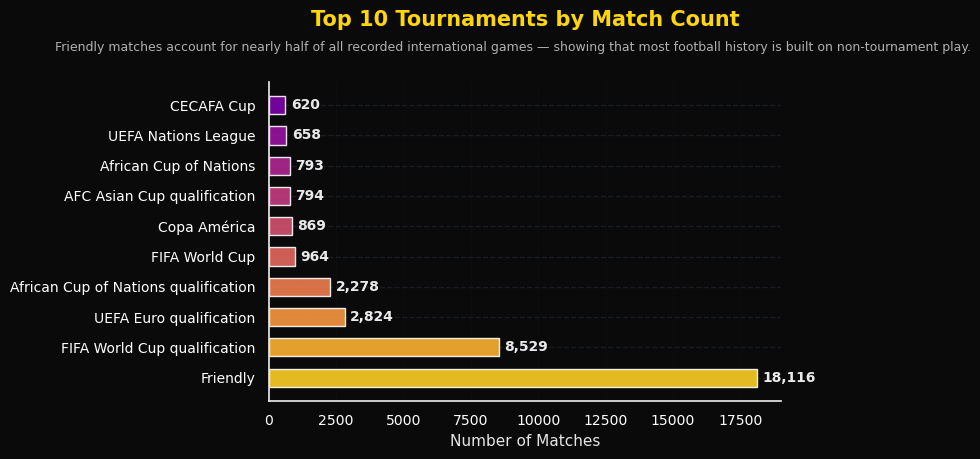

In [59]:
import matplotlib.pyplot as plt
import numpy as np

top_tournaments = df['tournament'].value_counts().head(10)[::-1]

background = '#0A0A0A'

fig, ax = plt.subplots(figsize=(9, 5), facecolor=background)
ax.set_facecolor(background)

bars = ax.barh(
    top_tournaments.index,
    top_tournaments.values,
    color=plt.cm.plasma(np.linspace(0.25, 0.9, 10)),
    alpha=0.9,
    height=0.6
)

for bar in bars:
    ax.text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height()/2,
        f"{int(bar.get_width()):,}",
        va='center',
        fontsize=10,
        color='#EAEAEA',
        fontweight='bold'
    )

ax.set_title(
    "Top 10 Tournaments by Match Count",
    fontsize=15,
    weight='bold',
    color='#FFD60A',
    pad=40
)

ax.set_xlabel("Number of Matches", fontsize=11)
ax.set_ylabel("")
ax.tick_params(colors='white', labelsize=10)
ax.grid(axis='x', alpha=0.2, linestyle='--', linewidth=0.5)
ax.invert_yaxis()

ax.text(
    top_tournaments.values.max() / 2,
    -1.8,
    "Friendly matches account for nearly half of all recorded international games — "
    "showing that most football history is built on non-tournament play.",
    ha='center',
    color='#B0B0B0',
    fontsize=9
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

fig.savefig("3.png", dpi=400, bbox_inches='tight', facecolor=background)

plt.show()
plt.close(fig)

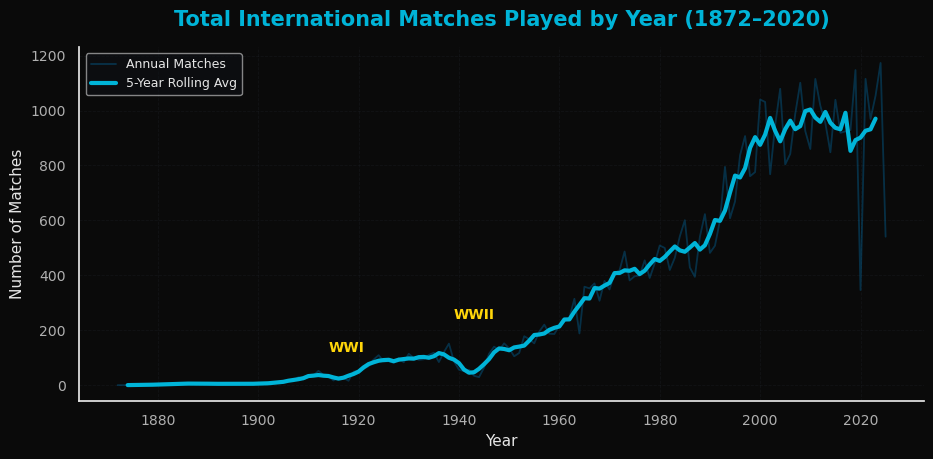

In [60]:
import matplotlib.pyplot as plt

matches_per_year = df.groupby('year').size()
rolling_mean = matches_per_year.rolling(window=5, center=True).mean()

background = '#0A0A0A'

fig, ax = plt.subplots(figsize=(10, 5), facecolor=background)
ax.set_facecolor(background)

ax.plot(matches_per_year.index, matches_per_year.values,
        color='#0077B6', alpha=0.35, linewidth=1.3, label='Annual Matches')

ax.plot(rolling_mean.index, rolling_mean.values,
        color='#00B4D8', linewidth=3, label='5-Year Rolling Avg')

ax.set_title("Total International Matches Played by Year (1872–2020)",
             fontsize=15, color='#00B4D8', weight='bold', pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Number of Matches", fontsize=11)
ax.grid(alpha=0.3, linestyle='--', linewidth=0.6)
ax.legend(facecolor='#0e1117', framealpha=0.5, edgecolor='white', fontsize=9)

ax.text(1914, 120, "WWI", color='#FFD60A', fontsize=10, fontweight='bold')
ax.text(1939, 240, "WWII", color='#FFD60A', fontsize=10, fontweight='bold')

plt.tight_layout(rect=[0, 0.05, 0.95, 1])

fig.savefig("4.png", dpi=400, bbox_inches='tight', facecolor=background)

plt.show()
plt.close(fig)

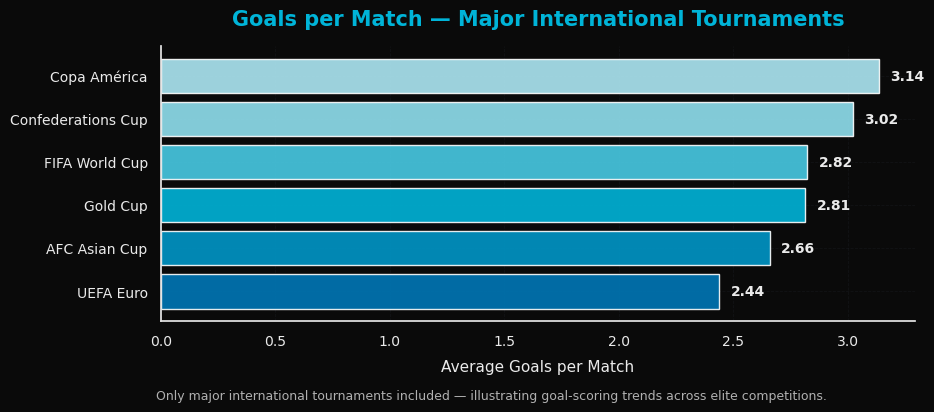

In [61]:
import matplotlib.pyplot as plt
import pandas as pd

major_df = df[df["is_major_tournament"] == True]

major_tournaments = (
    major_df.groupby("tournament")[["home_score", "away_score"]]
    .mean()
    .sum(axis=1)
    .sort_values(ascending=False)
)

background = '#0A0A0A'

fig, ax = plt.subplots(figsize=(10, 5), facecolor=background)
ax.set_facecolor(background)

bars = ax.barh(
    major_tournaments.index[::-1],
    major_tournaments.values[::-1],
    color=['#0077B6', '#0096C7', '#00B4D8', '#48CAE4', '#90E0EF', '#ADE8F4'],
    alpha=0.9
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va='center',
        ha='left',
        fontsize=10,
        color='#EAEAEA',
        fontweight='bold'
    )

ax.set_title("Goals per Match — Major International Tournaments",
             fontsize=15, color='#00B4D8', weight='bold', pad=15)
ax.set_xlabel("Average Goals per Match", fontsize=11, color='#EAEAEA', labelpad=8)
ax.set_ylabel("")
ax.grid(alpha=0.3, linestyle='--', linewidth=0.6)
ax.tick_params(axis='x', colors='#EAEAEA')
ax.tick_params(axis='y', colors='#EAEAEA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(-0.02, -2.5,
        "Only major international tournaments included — illustrating goal-scoring trends across elite competitions.",
        color='#B0B0B0', fontsize=9, ha='left')

plt.tight_layout(rect=[0, 0.08, 0.95, 1])

fig.savefig("5.png", dpi=400, bbox_inches='tight', facecolor=background)

plt.show()
plt.close(fig)

In [62]:
df["home_team"].unique()

array(['Scotland', 'England', 'Wales', 'Northern Ireland',
       'United States', 'Uruguay', 'Austria', 'Hungary', 'Argentina',
       'Belgium', 'France', 'Guernsey', 'Jersey', 'Netherlands', 'Guyana',
       'Czechoslovakia', 'Alderney', 'Switzerland', 'Sweden', 'Germany',
       'Italy', 'Chile', 'Norway', 'Russia', 'Finland', 'Luxembourg',
       'Denmark', 'Catalonia', 'Philippines', 'Basque Country',
       'China PR', 'Brazil', 'Japan', 'Paraguay', 'Greece', 'Spain',
       'Egypt', 'Suriname', 'Canada', 'Estonia', 'Costa Rica',
       'Guatemala', 'Brittany', 'Poland', 'Yugoslavia', 'New Zealand',
       'Romania', 'Latvia', 'Galicia', 'Portugal', 'Andalusia',
       'Australia', 'Lithuania', 'Turkey', 'Central Spain', 'Mexico',
       'Aruba', 'Republic of Ireland', 'Haiti', 'Bulgaria', 'Jamaica',
       'Kenya', 'Bolivia', 'Peru', 'Honduras', 'Uganda', 'Belarus',
       'El Salvador', 'Barbados', 'Trinidad and Tobago', 'Cuba',
       'Curaçao', 'Dominica', 'Silesia', 'Guadel

In [63]:
continent_map = {
    # ---- EUROPE ----
    'Scotland':'Europe','England':'Europe','Wales':'Europe','Northern Ireland':'Europe',
    'Republic of Ireland':'Europe','Germany':'Europe','France':'Europe','Italy':'Europe',
    'Spain':'Europe','Portugal':'Europe','Netherlands':'Europe','Belgium':'Europe',
    'Sweden':'Europe','Norway':'Europe','Denmark':'Europe','Finland':'Europe',
    'Poland':'Europe','Austria':'Europe','Hungary':'Europe','Switzerland':'Europe',
    'Czech Republic':'Europe','Czechoslovakia':'Europe','Slovakia':'Europe',
    'Serbia':'Europe','Croatia':'Europe','Bosnia and Herzegovina':'Europe',
    'Montenegro':'Europe','Slovenia':'Europe','Greece':'Europe','Turkey':'Europe',
    'Romania':'Europe','Bulgaria':'Europe','Albania':'Europe','Ukraine':'Europe',
    'Belarus':'Europe','Moldova':'Europe','Lithuania':'Europe','Latvia':'Europe',
    'Estonia':'Europe','Iceland':'Europe','Luxembourg':'Europe','Andorra':'Europe',
    'Malta':'Europe','San Marino':'Europe','Monaco':'Europe','Liechtenstein':'Europe',
    'Faroe Islands':'Europe','Kosovo':'Europe','Gibraltar':'Europe','Vatican City':'Europe',
    'Shetland':'Europe','Isle of Wight':'Europe','Isle of Man':'Europe',
    'Guernsey':'Europe','Jersey':'Europe','Alderney':'Europe','Åland Islands':'Europe',
    'Corsica':'Europe','Gotland':'Europe','Saare County':'Europe','Menorca':'Europe',
    'Provence':'Europe','Ticino':'Europe','Yorkshire':'Europe','Madrid':'Europe',
    'Franconia':'Europe','Padania':'Europe','County of Nice':'Europe','Ticino':'Europe',
    'Sápmi':'Europe','Felvidék':'Europe','Délvidék':'Europe','Székely Land':'Europe',
    'Western Isles':'Europe','Occitania':'Europe','Catalonia':'Europe','Basque Country':'Europe',
    'Galicia':'Europe','Brittany':'Europe','Central Spain':'Europe','Andalusia':'Europe',
    'Sark':'Europe','Raetia':'Europe','Gozo':'Europe','Ticino':'Europe','Saugeais':'Europe',
    'Yugoslavia':'Europe','German DR':'Europe','Saarland':'Europe','Chechnya':'Europe',
    'Luhansk PR':'Europe','Donetsk PR':'Europe',

    # ---- NORTH AMERICA ----
    'United States':'North America','Canada':'North America','Mexico':'North America',
    'Costa Rica':'North America','Honduras':'North America','El Salvador':'North America',
    'Guatemala':'North America','Panama':'North America','Jamaica':'North America',
    'Haiti':'North America','Cuba':'North America','Dominica':'North America',
    'Dominican Republic':'North America','Puerto Rico':'North America','Nicaragua':'North America',
    'Trinidad and Tobago':'North America','Saint Kitts and Nevis':'North America',
    'Saint Lucia':'North America','Grenada':'North America',
    'Barbados':'North America','Saint Vincent and the Grenadines':'North America',
    'Antigua and Barbuda':'North America','Bahamas':'North America','Belize':'North America',
    'Bermuda':'North America','Cayman Islands':'North America','Turks and Caicos Islands':'North America',
    'Montserrat':'North America','Guadeloupe':'North America','Martinique':'North America',
    'Saint Martin':'North America','Saint Barthélemy':'North America','Sint Maarten':'North America',
    'British Virgin Islands':'North America','United States Virgin Islands':'North America',

    # ---- SOUTH AMERICA ----
    'Brazil':'South America','Argentina':'South America','Uruguay':'South America',
    'Chile':'South America','Paraguay':'South America','Peru':'South America',
    'Colombia':'South America','Ecuador':'South America','Venezuela':'South America',
    'Bolivia':'South America','Suriname':'South America','Guyana':'South America',
    'French Guiana':'South America',

    # ---- AFRICA ----
    'Egypt':'Africa','Morocco':'Africa','Tunisia':'Africa','Algeria':'Africa','Libya':'Africa',
    'Nigeria':'Africa','Ghana':'Africa','Cameroon':'Africa','Senegal':'Africa',
    'Ivory Coast':'Africa','South Africa':'Africa','Zimbabwe':'Africa','Zambia':'Africa',
    'Uganda':'Africa','Kenya':'Africa','Ethiopia':'Africa','Tanzania':'Africa','Angola':'Africa',
    'Mozambique':'Africa','Malawi':'Africa','Mali':'Africa','Burkina Faso':'Africa','Benin':'Africa',
    'Niger':'Africa','Togo':'Africa','Congo':'Africa','DR Congo':'Africa','Gabon':'Africa',
    'Guinea':'Africa','Guinea-Bissau':'Africa','Cape Verde':'Africa','Sudan':'Africa',
    'South Sudan':'Africa','Central African Republic':'Africa','Chad':'Africa',
    'Mauritania':'Africa','Senegal':'Africa','Sierra Leone':'Africa','Liberia':'Africa',
    'Djibouti':'Africa','Somalia':'Africa','Eritrea':'Africa','Rwanda':'Africa','Burundi':'Africa',
    'Equatorial Guinea':'Africa','São Tomé and Príncipe':'Africa','Seychelles':'Africa',
    'Comoros':'Africa','Eswatini':'Africa','Lesotho':'Africa','Botswana':'Africa',
    'Namibia':'Africa','Western Sahara':'Africa','Reunion':'Africa','Mayotte':'Africa',
    'Zanzibar':'Africa','Matabeleland':'Africa','Kabylia':'Africa','Yoruba Nation':'Africa',
    'Biafra':'Africa','Darfur':'Africa','Somaliland':'Africa',

    # ---- ASIA ----
    'Japan':'Asia','China PR':'Asia','South Korea':'Asia','North Korea':'Asia',
    'Iran':'Asia','Iraq':'Asia','Saudi Arabia':'Asia','Qatar':'Asia','United Arab Emirates':'Asia',
    'Kuwait':'Asia','Bahrain':'Asia','Oman':'Asia','Yemen':'Asia','Yemen DPR':'Asia',
    'Israel':'Asia','Lebanon':'Asia','Syria':'Asia','Jordan':'Asia','Palestine':'Asia',
    'Afghanistan':'Asia','Pakistan':'Asia','India':'Asia','Sri Lanka':'Asia','Bangladesh':'Asia',
    'Nepal':'Asia','Bhutan':'Asia','Myanmar':'Asia','Thailand':'Asia','Vietnam':'Asia',
    'Vietnam Republic':'Asia','North Vietnam':'Asia','Laos':'Asia','Cambodia':'Asia',
    'Malaysia':'Asia','Singapore':'Asia','Indonesia':'Asia','Philippines':'Asia','Macau':'Asia',
    'Hong Kong':'Asia','Taiwan':'Asia','Uzbekistan':'Asia','Kazakhstan':'Asia',
    'Turkmenistan':'Asia','Kyrgyzstan':'Asia','Tajikistan':'Asia','Georgia':'Asia',
    'Armenia':'Asia','Azerbaijan':'Asia','Mongolia':'Asia','Brunei':'Asia',
    'Tibet':'Asia','Western Armenia':'Asia','Chechnya':'Asia','Panjab':'Asia',
    'Iraqi Kurdistan':'Asia','Tamil Eelam':'Asia','Ryūkyū':'Asia','Gozo':'Europe',

    # ---- OCEANIA ----
    'Australia':'Oceania','New Zealand':'Oceania','Fiji':'Oceania','Tahiti':'Oceania',
    'New Caledonia':'Oceania','Solomon Islands':'Oceania','Papua New Guinea':'Oceania',
    'Vanuatu':'Oceania','Samoa':'Oceania','American Samoa':'Oceania','Tonga':'Oceania',
    'Micronesia':'Oceania','Kiribati':'Oceania','Tuvalu':'Oceania','Niue':'Oceania',
    'Wallis Islands and Futuna':'Oceania','Cook Islands':'Oceania','Palau':'Oceania',
    'Guam':'Oceania','Northern Mariana Islands':'Oceania',

    # ---- OTHER / REGIONAL OR NON-FIFA ----
    'Catalonia':'Europe','Basque Country':'Europe','Padania':'Europe','Sápmi':'Europe',
    'Occitania':'Europe','Franconia':'Europe','Chameria':'Europe','County of Nice':'Europe',
    'Provence':'Europe','Western Armenia':'Asia','Abkhazia':'Asia','South Ossetia':'Asia',
    'Artsakh':'Asia','Barawa':'Africa','Kabylia':'Africa','Mapuche':'South America',
    'Aymara':'South America','Cascadia':'North America','Sealand':'Europe','Raetia':'Europe',
    'Sark':'Europe','Ellan Vannin':'Europe','Republic of St. Pauli':'Europe','Romani people':'Europe',
    'Ticino':'Europe','Western Australia':'Oceania','Yorkshire':'Europe','Isle of Wight':'Europe',
    'Kernow':'Europe','Frøya':'Europe','Hitra':'Europe'
}

df['home_team_continent'] = df['country'].map(continent_map).fillna('Other')

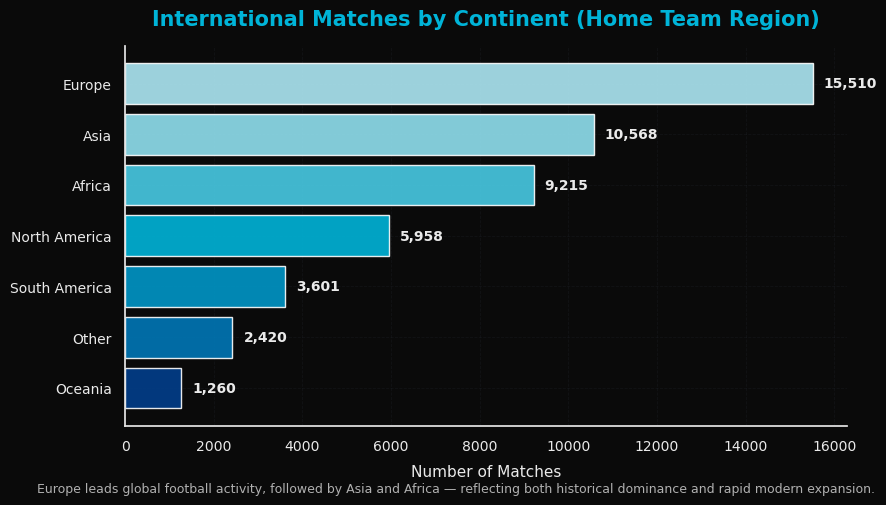

In [64]:
continent_counts = (
    df.groupby("home_team_continent")
    .size()
    .sort_values(ascending=True)
)

background = '#0A0A0A'

fig, ax = plt.subplots(figsize=(9.5, 5.8), facecolor=background)
ax.set_facecolor(background)

bars = ax.barh(
    continent_counts.index,
    continent_counts.values,
    color=['#023E8A', '#0077B6', '#0096C7', '#00B4D8', '#48CAE4', '#90E0EF', '#ADE8F4'],
    alpha=0.9
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 250,  # spacing optimize edildi
        bar.get_y() + bar.get_height() / 2,
        f"{width:,}",
        va='center',
        ha='left',
        fontsize=10,
        color='#EAEAEA',
        fontweight='bold'
    )
ax.set_title("International Matches by Continent (Home Team Region)",
             fontsize=15, color='#00B4D8', weight='bold', pad=15)
ax.set_xlabel("Number of Matches", fontsize=11, color='#EAEAEA', labelpad=8)
ax.set_ylabel("")
ax.grid(alpha=0.3, linestyle='--', linewidth=0.6)
ax.tick_params(axis='x', colors='#EAEAEA')
ax.tick_params(axis='y', colors='#EAEAEA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(-2000, -2.05,
        "Europe leads global football activity, followed by Asia and Africa — reflecting both historical dominance and rapid modern expansion.",
        color='#B0B0B0', fontsize=9, ha='left')

plt.tight_layout(rect=[0, 0.08, 0.95, 1])

fig.savefig("6.png", dpi=400, bbox_inches='tight', facecolor=background)

plt.show()
plt.close(fig)

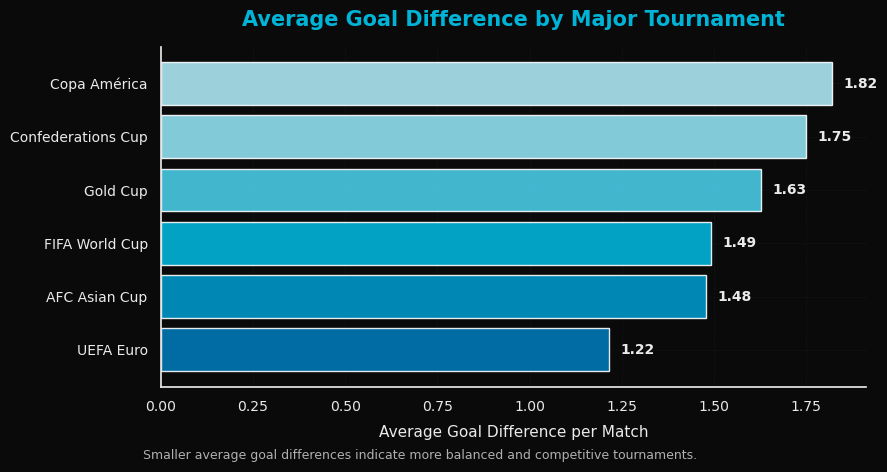

In [65]:
major_df = df[df["is_major_tournament"] == True].copy()

major_df["goal_difference"] = (major_df["home_score"] - major_df["away_score"]).abs()

goal_diff_by_tournament = (
    major_df.groupby("tournament")["goal_difference"]
    .mean()
    .sort_values(ascending=False)
)

background = '#0A0A0A'

fig, ax = plt.subplots(figsize=(9.5, 5.5), facecolor=background)
ax.set_facecolor(background)

bars = ax.barh(
    goal_diff_by_tournament.index[::-1],
    goal_diff_by_tournament.values[::-1],
    color=['#0077B6', '#0096C7', '#00B4D8', '#48CAE4', '#90E0EF', '#ADE8F4'],
    alpha=0.9
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va='center',
        ha='left',
        fontsize=10,
        color='#EAEAEA',
        fontweight='bold'
    )

ax.set_title("Average Goal Difference by Major Tournament",
             fontsize=15, color='#00B4D8', weight='bold', pad=15)
ax.set_xlabel("Average Goal Difference per Match", fontsize=11, color='#EAEAEA', labelpad=8)
ax.set_ylabel("")
ax.grid(alpha=0.3, linestyle='--', linewidth=0.6)
ax.tick_params(axis='x', colors='#EAEAEA')
ax.tick_params(axis='y', colors='#EAEAEA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(-0.05, -2.05,
        "Smaller average goal differences indicate more balanced and competitive tournaments.",
        color='#B0B0B0', fontsize=9, ha='left')

plt.tight_layout(rect=[0, 0.08, 0.95, 1])

fig.savefig("7.png", dpi=400, bbox_inches='tight', facecolor=background)

plt.show()
plt.close(fig)

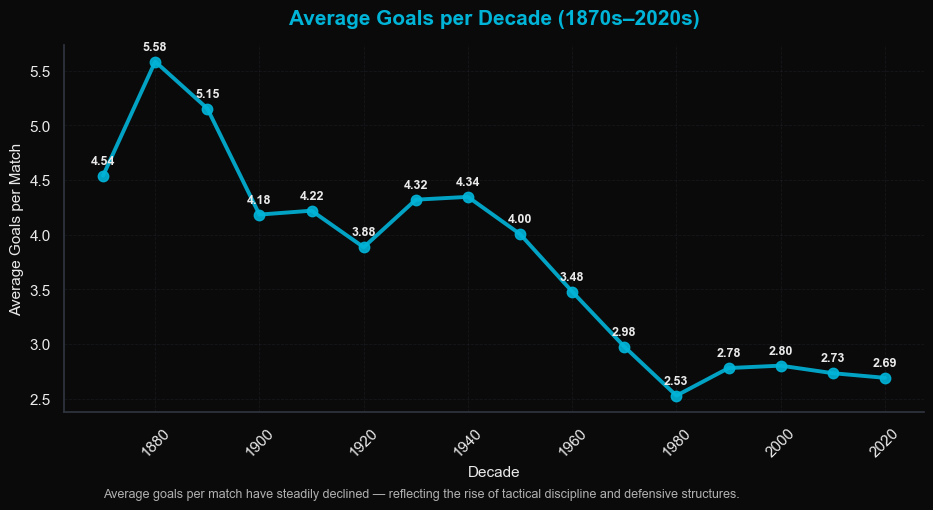

In [80]:
goals_per_decade = (
    df.groupby("decade")[["home_score", "away_score"]]
    .mean()
    .sum(axis=1)
    .sort_index()
)

background = '#0A0A0A'

fig, ax = plt.subplots(figsize=(10, 5.8), facecolor=background)
ax.set_facecolor(background)

ax.plot(
    goals_per_decade.index,
    goals_per_decade.values,
    color='#00B4D8',
    linewidth=2.8,
    marker='o',
    markersize=7.5,
    alpha=0.9
)

for x, y in zip(goals_per_decade.index, goals_per_decade.values):
    ax.text(
        x,
        y + 0.08,
        f"{y:.2f}",
        ha='center',
        va='bottom',
        fontsize=9,
        color='#EAEAEA',
        fontweight='bold'
    )

ax.set_title(
    "Average Goals per Decade (1870s–2020s)",
    fontsize=15,
    color='#00B4D8',
    weight='bold',
    pad=15
)
ax.set_xlabel("Decade", fontsize=11, color='#EAEAEA')
ax.set_ylabel("Average Goals per Match", fontsize=11, color='#EAEAEA')

ax.grid(alpha=0.3, linestyle='--', linewidth=0.6)
ax.tick_params(axis='x', colors='#EAEAEA', rotation=45)
ax.tick_params(axis='y', colors='#EAEAEA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(
    1870,
    1.6,
    "Average goals per match have steadily declined — reflecting the rise of tactical discipline and defensive structures.",
    color='#B0B0B0',
    fontsize=9,
    ha='left'
)

plt.tight_layout(rect=[0, 0.06, 0.95, 1])
fig.savefig("8.png", dpi=400, bbox_inches='tight', facecolor=background)

plt.show()
plt.close(fig)

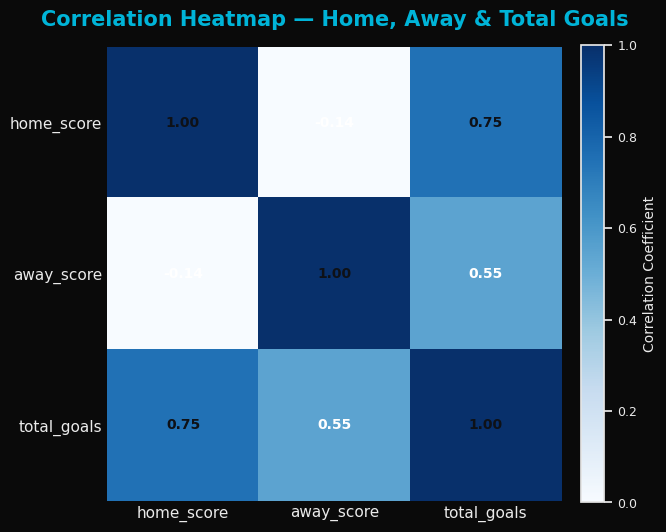

In [67]:
import matplotlib.pyplot as plt

corr = df[["home_score", "away_score", "total_goals"]].corr()
background = '#0A0A0A'

fig, ax = plt.subplots(figsize=(6.8, 5.8), facecolor=background)
ax.set_facecolor(background)

im = ax.imshow(corr, cmap="Blues", vmin=0, vmax=1)

ax.set_title(
    "Correlation Heatmap — Home, Away & Total Goals",
    fontsize=15,
    color='#00B4D8',
    weight='bold',
    pad=15
)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, fontsize=11, color='#EAEAEA')
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=11, color='#EAEAEA')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(colors='#EAEAEA', labelsize=9)
cbar.set_label('Correlation Coefficient', color='#EAEAEA', fontsize=10)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        value = corr.iloc[i, j]
        text_color = '#0E1117' if value > 0.65 else '#FFFFFF'
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha='center',
            va='center',
            color=text_color,
            fontsize=10,
            fontweight='bold'
        )

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(False)
ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout(rect=[0, 0.05, 0.95, 1])
fig.savefig("9.png", dpi=400, bbox_inches='tight', facecolor=background)

plt.show()
plt.close(fig)


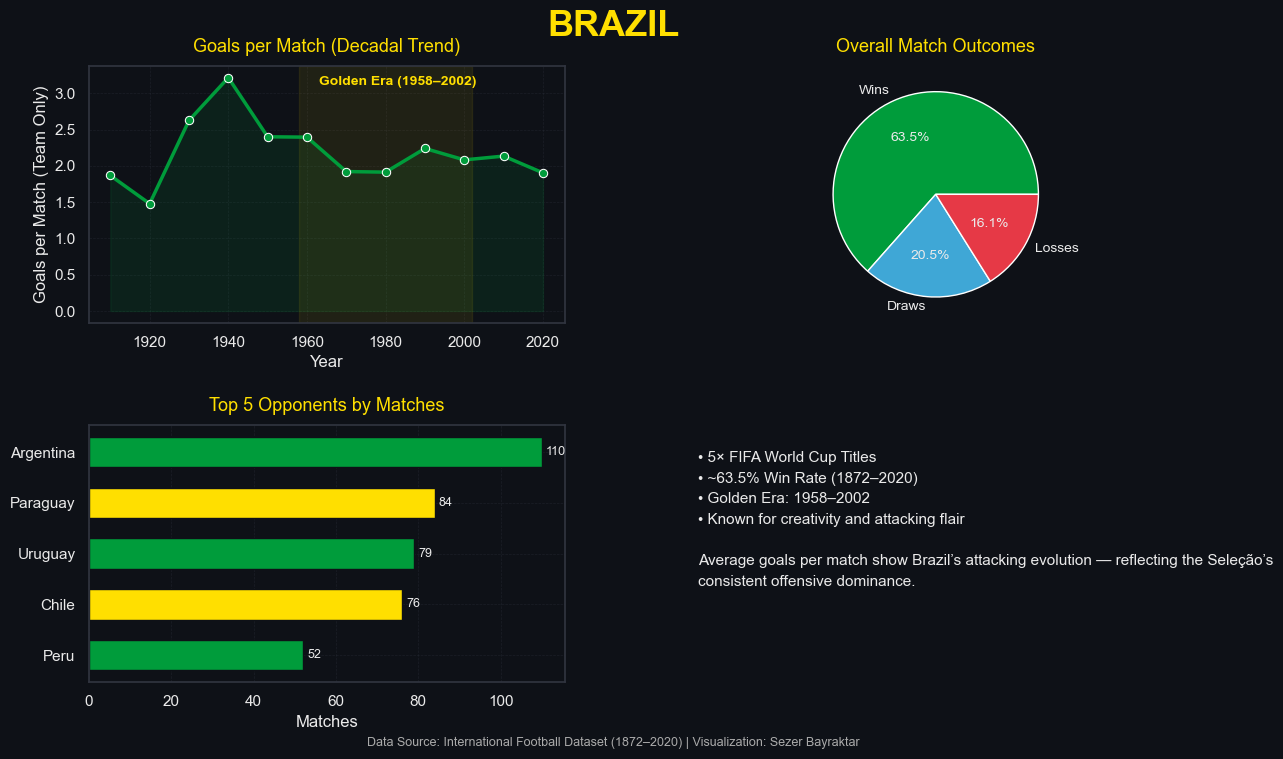

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def get_country_data(df, country):
    df_country = df[(df['home_team'] == country) | (df['away_team'] == country)].copy()
    df_country['Opponent'] = df_country.apply(
        lambda x: x['away_team'] if x['home_team'] == country else x['home_team'], axis=1
    )
    top_opponents = (
        df_country['Opponent']
        .value_counts()
        .head(5)
        .reset_index()
    )
    top_opponents.columns = ['Opponent', 'Matches']
    return df_country, top_opponents

plt.style.use("dark_background")
background = "#0e1117"
green = "#009C3B"
yellow = "#FFDF00"
blue = "#3FA7D6"
red = "#E63946"
text = "#EAEAEA"
grid = "#30343F"

sns.set(rc={
    'axes.facecolor': background,
    'figure.facecolor': background,
    'axes.edgecolor': grid,
    'axes.labelcolor': text,
    'text.color': text,
    'xtick.color': text,
    'ytick.color': text,
    'grid.color': grid,
    'axes.titlesize': 13,
    'axes.titlecolor': yellow
})

country = "Brazil"
df_brazil, top_opponents = get_country_data(df, country)

df_brazil['team_goals'] = df_brazil.apply(
    lambda x: x['home_score'] if x['home_team'] == country else x['away_score'],
    axis=1
)

goals_trend = (
    df_brazil.groupby('decade')['team_goals']
    .mean()
    .reset_index()
    .rename(columns={'team_goals': 'Goals_per_Match'})
)

total_matches = len(df_brazil)
wins = ((df_brazil['home_team'] == country) & df_brazil['is_home_win']).sum() + \
       ((df_brazil['away_team'] == country) & df_brazil['is_away_win']).sum()
draws = df_brazil['is_draw'].sum()
losses = total_matches - wins - draws

fig = plt.figure(figsize=(14, 8), facecolor=background)
fig.suptitle("BRAZIL", fontsize=26, color=yellow, fontweight="bold", y=0.95)
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])
sns.lineplot(data=goals_trend, x='decade', y='Goals_per_Match',
             color=green, marker='o', linewidth=2.5, ax=ax1)
ax1.fill_between(goals_trend['decade'], goals_trend['Goals_per_Match'], color=green, alpha=0.12)
ax1.set_title("Goals per Match (Decadal Trend)", pad=10)
ax1.set_ylabel("Goals per Match (Team Only)")
ax1.set_xlabel("Year")
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
ax1.axvspan(1958, 2002, color=yellow, alpha=0.08)
ax1.text(1963, goals_trend['Goals_per_Match'].max() - 0.1,
         "Golden Era (1958–2002)", color=yellow, fontsize=10, fontweight="bold")

ax2 = fig.add_subplot(gs[0, 1])
ax2.pie([wins, draws, losses],
        labels=['Wins', 'Draws', 'Losses'],
        colors=[green, blue, red],
        autopct='%1.1f%%',
        textprops={'color': text, 'fontsize': 10})
ax2.set_title("Overall Match Outcomes", pad=10)

ax3 = fig.add_subplot(gs[1, 0])
ax3.set_title("Top 5 Opponents by Matches", color=yellow, pad=10)
ax3.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

colors = [green if i % 2 == 0 else yellow for i in range(len(top_opponents))]
for i, (opp, val) in enumerate(zip(top_opponents['Opponent'], top_opponents['Matches'])):
    ax3.barh(i, val, color=colors[i], edgecolor=background, height=0.6)
    ax3.text(val + 1, i, f"{val}", va='center', color=text, fontsize=9)

ax3.set_yticks(range(len(top_opponents)))
ax3.set_yticklabels(top_opponents['Opponent'], color=text)
ax3.set_xlabel("Matches", color=text)
ax3.invert_yaxis()

ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
info = (
    "• 5× FIFA World Cup Titles\n"
    "• ~63.5% Win Rate (1872–2020)\n"
    "• Golden Era: 1958–2002\n"
    "• Known for creativity and attacking flair\n\n"
    "Average goals per match show Brazil’s attacking evolution — "
    "reflecting the Seleção’s consistent offensive dominance."
)
ax4.text(0, 0.9, info, color=text, fontsize=11,
         va='top', ha='left', wrap=True, linespacing=1.6)

fig.text(
    0.5, 0.03,
    "Data Source: International Football Dataset (1872–2020) | Visualization: Sezer Bayraktar",
    ha='center', color='#AAAAAA', fontsize=9
)

fig.savefig("brazill.png", dpi=400, bbox_inches='tight', facecolor=background)
plt.show()

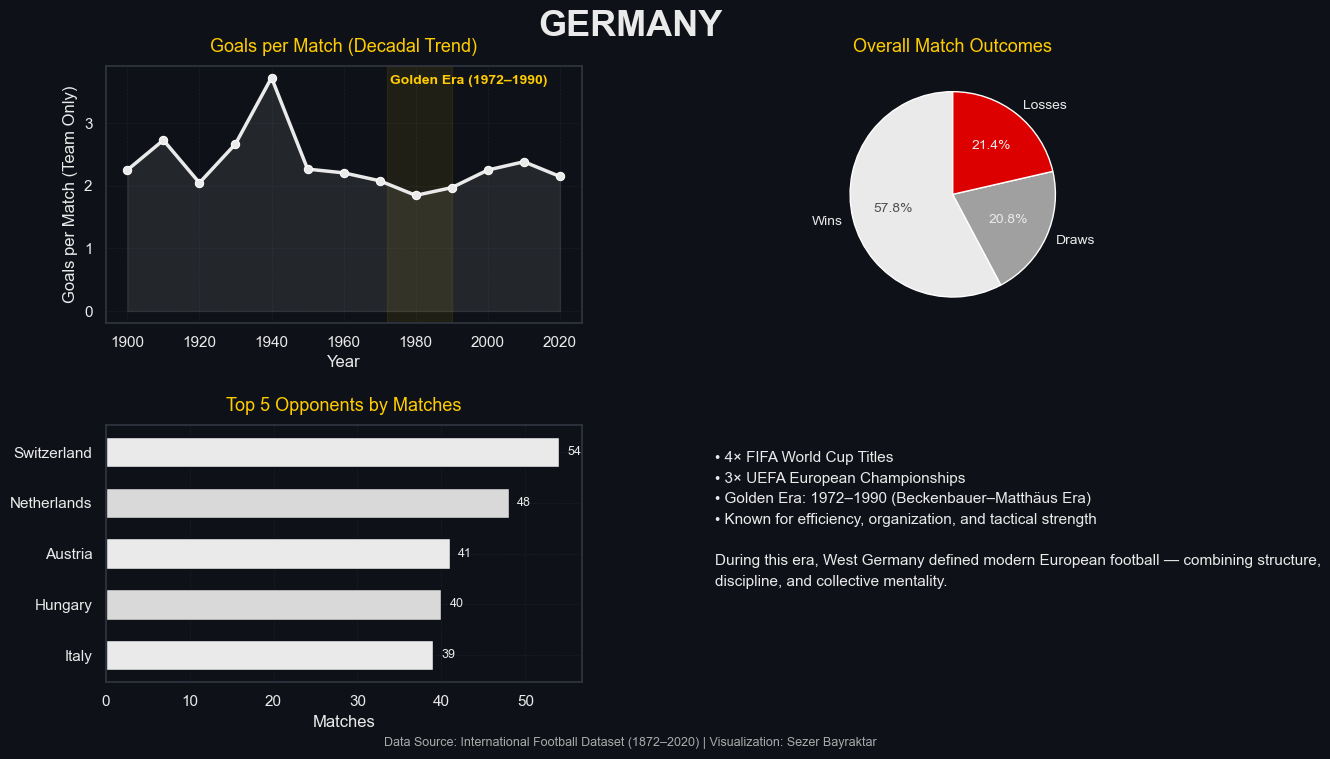

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors

def get_country_data(df, country, alt_names=None):
    if alt_names is None:
        alt_names = []
    all_names = [country] + alt_names
    df_country = df[
        (df['home_team'].isin(all_names)) | (df['away_team'].isin(all_names))
    ].copy()
    df_country['Opponent'] = df_country.apply(
        lambda x: x['away_team'] if x['home_team'] in all_names else x['home_team'], axis=1
    )
    top_opponents = (
        df_country['Opponent']
        .value_counts()
        .head(5)
        .reset_index()
    )
    top_opponents.columns = ['Opponent', 'Matches']
    return df_country, top_opponents

plt.style.use("dark_background")
background = "#0e1117"
white = "#EAEAEA"
gray_light = "#D9D9D9"
gray = "#A0A0A0"
dark_gray = "#505050"
red = "#DD0000"
text = "#EAEAEA"
grid = "#30343F"
accent = "#FFCC00"

sns.set(rc={
    'axes.facecolor': background,
    'figure.facecolor': background,
    'axes.edgecolor': grid,
    'axes.labelcolor': text,
    'text.color': text,
    'xtick.color': text,
    'ytick.color': text,
    'grid.color': grid,
    'axes.titlesize': 13,
    'axes.titlecolor': accent
})

country = "Germany"
alt_names = ["West Germany"]
df_germany, top_opponents = get_country_data(df, country, alt_names)

df_germany['team_goals'] = df_germany.apply(
    lambda x: x['home_score'] if x['home_team'] in [country] + alt_names else x['away_score'],
    axis=1
)

goals_trend = (
    df_germany.groupby('decade')['team_goals']
    .mean()
    .reset_index()
    .rename(columns={'team_goals': 'Goals_per_Match'})
)

total_matches = len(df_germany)
wins = ((df_germany['home_team'].isin([country] + alt_names)) & df_germany['is_home_win']).sum() + \
       ((df_germany['away_team'].isin([country] + alt_names)) & df_germany['is_away_win']).sum()
draws = df_germany['is_draw'].sum()
losses = total_matches - wins - draws

fig = plt.figure(figsize=(14, 8), facecolor=background)
fig.suptitle("GERMANY", fontsize=26, color=white, fontweight="bold", y=0.95)
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])
sns.lineplot(data=goals_trend, x='decade', y='Goals_per_Match',
             color=white, marker='o', linewidth=2.5, ax=ax1)
ax1.fill_between(goals_trend['decade'], goals_trend['Goals_per_Match'],
                 color=gray, alpha=0.15)
ax1.set_title("Goals per Match (Decadal Trend)", pad=10)
ax1.set_ylabel("Goals per Match (Team Only)")
ax1.set_xlabel("Year")
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
ax1.axvspan(1972, 1990, color=accent, alpha=0.08)
ax1.text(1973, goals_trend['Goals_per_Match'].max() - 0.1,
         "Golden Era (1972–1990)", color=accent, fontsize=10, fontweight="bold")

ax2 = fig.add_subplot(gs[0, 1])
colors = [white, gray, red]
wedges, texts, autotexts = ax2.pie(
    [wins, draws, losses],
    labels=['Wins', 'Draws', 'Losses'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)
for w, a in zip(wedges, autotexts):
    color = mcolors.to_rgb(w.get_facecolor())
    brightness = sum(color) / 3
    a.set_color(dark_gray if brightness > 0.7 else white)
ax2.set_title("Overall Match Outcomes", pad=10, color=accent)

ax3 = fig.add_subplot(gs[1, 0])
ax3.set_title("Top 5 Opponents by Matches", color=accent, pad=10)
ax3.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
colors = [white if i % 2 == 0 else gray_light for i in range(len(top_opponents))]
for i, (opp, val) in enumerate(zip(top_opponents['Opponent'], top_opponents['Matches'])):
    ax3.barh(i, val, color=colors[i], edgecolor=background, height=0.6)
    ax3.text(val + 1, i, f"{val}", va='center', color=text, fontsize=9)
ax3.set_yticks(range(len(top_opponents)))
ax3.set_yticklabels(top_opponents['Opponent'], color=text)
ax3.set_xlabel("Matches", color=text)
ax3.invert_yaxis()

ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
info = (
    "• 4× FIFA World Cup Titles\n"
    "• 3× UEFA European Championships\n"
    "• Golden Era: 1972–1990 (Beckenbauer–Matthäus Era)\n"
    "• Known for efficiency, organization, and tactical strength\n\n"
    "During this era, West Germany defined modern European football — "
    "combining structure, discipline, and collective mentality."
)
ax4.text(0, 0.9, info, color=text, fontsize=11,
         va='top', ha='left', wrap=True, linespacing=1.6)

fig.text(
    0.5, 0.03,
    "Data Source: International Football Dataset (1872–2020) | Visualization: Sezer Bayraktar",
    ha='center', color='#AAAAAA', fontsize=9
)
fig.savefig("germany.png", dpi=400, bbox_inches='tight', facecolor=background)
plt.show()

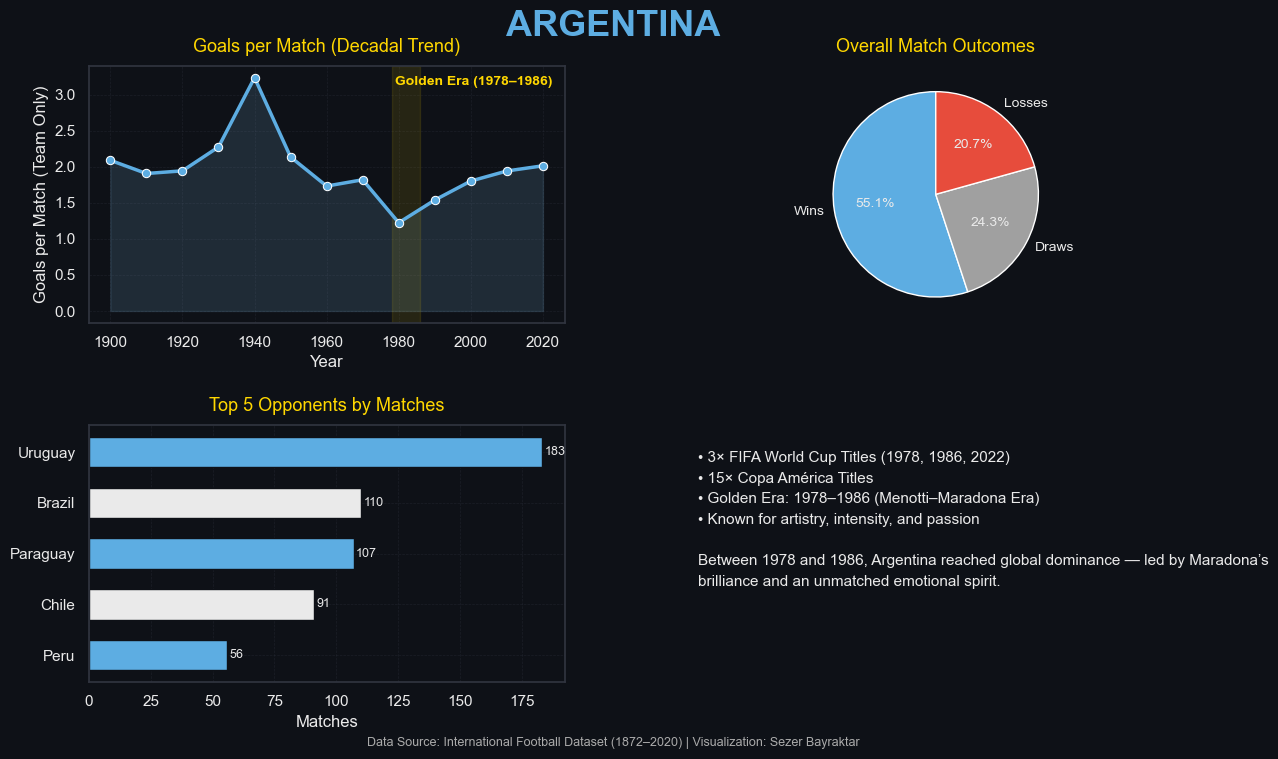

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors

def get_country_data(df, country, alt_names=None):
    if alt_names is None:
        alt_names = []
    all_names = [country] + alt_names
    df_country = df[
        (df['home_team'].isin(all_names)) | (df['away_team'].isin(all_names))
    ].copy()
    df_country['Opponent'] = df_country.apply(
        lambda x: x['away_team'] if x['home_team'] in all_names else x['home_team'], axis=1
    )
    top_opponents = (
        df_country['Opponent']
        .value_counts()
        .head(5)
        .reset_index()
    )
    top_opponents.columns = ['Opponent', 'Matches']
    return df_country, top_opponents

plt.style.use("dark_background")
background = "#0e1117"
white = "#EAEAEA"
sky_blue = "#5DADE2"
light_blue = "#85C1E9"
gray_light = "#D9D9D9"
gray = "#A0A0A0"
dark_gray = "#505050"
red = "#E74C3C"
text = "#EAEAEA"
grid = "#30343F"
accent = "#FFD700"

sns.set(rc={
    'axes.facecolor': background,
    'figure.facecolor': background,
    'axes.edgecolor': grid,
    'axes.labelcolor': text,
    'text.color': text,
    'xtick.color': text,
    'ytick.color': text,
    'grid.color': grid,
    'axes.titlesize': 13,
    'axes.titlecolor': accent
})

country = "Argentina"
df_arg, top_opponents = get_country_data(df, country)

df_arg['team_goals'] = df_arg.apply(
    lambda x: x['home_score'] if x['home_team'] == country else x['away_score'],
    axis=1
)

goals_trend = (
    df_arg.groupby('decade')['team_goals']
    .mean()
    .reset_index()
    .rename(columns={'team_goals': 'Goals_per_Match'})
)

total_matches = len(df_arg)
wins = ((df_arg['home_team'] == country) & df_arg['is_home_win']).sum() + \
       ((df_arg['away_team'] == country) & df_arg['is_away_win']).sum()
draws = df_arg['is_draw'].sum()
losses = total_matches - wins - draws

fig = plt.figure(figsize=(14, 8), facecolor=background)
fig.suptitle("ARGENTINA", fontsize=26, color=sky_blue, fontweight="bold", y=0.95)
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])
sns.lineplot(data=goals_trend, x='decade', y='Goals_per_Match',
             color=sky_blue, marker='o', linewidth=2.5, ax=ax1)
ax1.fill_between(goals_trend['decade'], goals_trend['Goals_per_Match'],
                 color=light_blue, alpha=0.15)
ax1.set_title("Goals per Match (Decadal Trend)", pad=10)
ax1.set_ylabel("Goals per Match (Team Only)")
ax1.set_xlabel("Year")
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
ax1.axvspan(1978, 1986, color=accent, alpha=0.1)
ax1.text(1979, goals_trend['Goals_per_Match'].max() - 0.1,
         "Golden Era (1978–1986)", color=accent, fontsize=10, fontweight="bold")

ax2 = fig.add_subplot(gs[0, 1])
colors = [sky_blue, gray, red]
wedges, texts, autotexts = ax2.pie(
    [wins, draws, losses],
    labels=['Wins', 'Draws', 'Losses'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)
for w, a in zip(wedges, autotexts):
    color = mcolors.to_rgb(w.get_facecolor())
    brightness = sum(color) / 3
    a.set_color(dark_gray if brightness > 0.7 else white)
ax2.set_title("Overall Match Outcomes", pad=10, color=accent)

ax3 = fig.add_subplot(gs[1, 0])
ax3.set_title("Top 5 Opponents by Matches", color=accent, pad=10)
ax3.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
colors = [sky_blue if i % 2 == 0 else white for i in range(len(top_opponents))]
for i, (opp, val) in enumerate(zip(top_opponents['Opponent'], top_opponents['Matches'])):
    ax3.barh(i, val, color=colors[i], edgecolor=background, height=0.6)
    ax3.text(val + 1, i, f"{val}", va='center', color=text, fontsize=9)
ax3.set_yticks(range(len(top_opponents)))
ax3.set_yticklabels(top_opponents['Opponent'], color=text)
ax3.set_xlabel("Matches", color=text)
ax3.invert_yaxis()

ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
info = (
    "• 3× FIFA World Cup Titles (1978, 1986, 2022)\n"
    "• 15× Copa América Titles\n"
    "• Golden Era: 1978–1986 (Menotti–Maradona Era)\n"
    "• Known for artistry, intensity, and passion\n\n"
    "Between 1978 and 1986, Argentina reached global dominance — "
    "led by Maradona’s brilliance and an unmatched emotional spirit."
)
ax4.text(0, 0.9, info, color=text, fontsize=11,
         va='top', ha='left', wrap=True, linespacing=1.6)

fig.text(
    0.5, 0.03,
    "Data Source: International Football Dataset (1872–2020) | Visualization: Sezer Bayraktar",
    ha='center', color='#AAAAAA', fontsize=9
)
fig.savefig("argentina.png", dpi=400, bbox_inches='tight', facecolor=background)
plt.show()


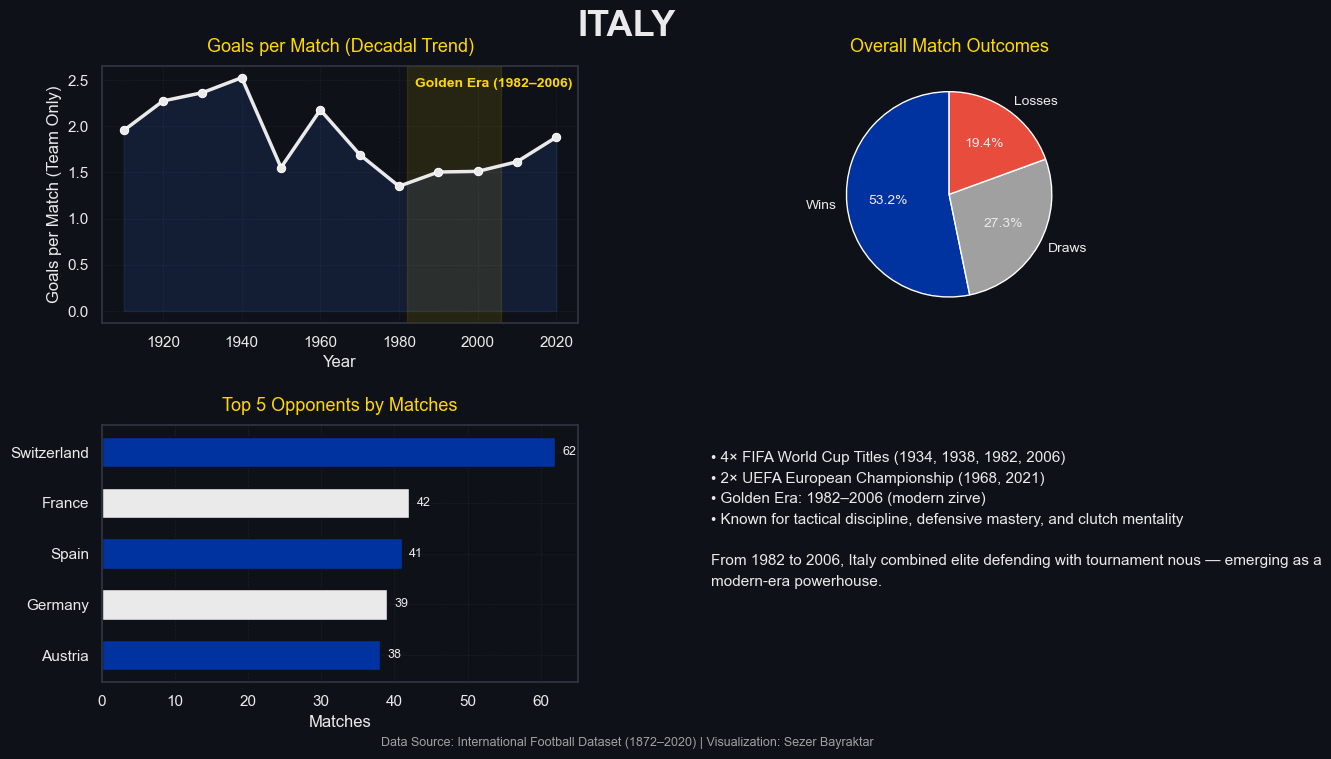

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors

def get_country_data(df, country, alt_names=None):
    if alt_names is None:
        alt_names = []
    all_names = [country] + alt_names
    df_country = df[(df['home_team'].isin(all_names)) | (df['away_team'].isin(all_names))].copy()
    df_country['Opponent'] = df_country.apply(
        lambda x: x['away_team'] if x['home_team'] in all_names else x['home_team'], axis=1
    )
    top_opp = (
        df_country['Opponent']
        .value_counts()
        .head(5)
        .reset_index()
    )
    top_opp.columns = ['Opponent', 'Matches']
    return df_country, top_opp

plt.style.use("dark_background")
background = "#0e1117"
azzurri = "#0033A0"
azzurri_lt = "#2F5ABF"
white = "#EAEAEA"
gray = "#A0A0A0"
gray_lt = "#D9D9D9"
dark_gray = "#505050"
red = "#E74C3C"
accent = "#FFD700"
grid = "#30343F"

sns.set(rc={
    'axes.facecolor': background,
    'figure.facecolor': background,
    'axes.edgecolor': grid,
    'axes.labelcolor': white,
    'text.color': white,
    'xtick.color': white,
    'ytick.color': white,
    'grid.color': grid,
    'axes.titlesize': 13,
    'axes.titlecolor': accent
})

country = "Italy"
df_ita, top_opponents = get_country_data(df, country)

df_ita['team_goals'] = df_ita.apply(
    lambda x: x['home_score'] if x['home_team'] == country else x['away_score'],
    axis=1
)

goals_trend = (
    df_ita.groupby('decade')['team_goals']
    .mean()
    .reset_index()
    .rename(columns={'team_goals': 'Goals_per_Match'})
)

total_matches = len(df_ita)
wins = ((df_ita['home_team'] == country) & df_ita['is_home_win']).sum() + \
       ((df_ita['away_team'] == country) & df_ita['is_away_win']).sum()
draws = df_ita['is_draw'].sum()
losses = total_matches - wins - draws

fig = plt.figure(figsize=(14, 8), facecolor=background)
fig.suptitle("ITALY", fontsize=26, color=white, fontweight="bold", y=0.95)
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])
sns.lineplot(data=goals_trend, x='decade', y='Goals_per_Match',
             color=white, marker='o', linewidth=2.5, ax=ax1)
ax1.fill_between(goals_trend['decade'], goals_trend['Goals_per_Match'],
                 color=azzurri_lt, alpha=0.18)
ax1.set_title("Goals per Match (Decadal Trend)", pad=10)
ax1.set_ylabel("Goals per Match (Team Only)")
ax1.set_xlabel("Year")
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
ax1.axvspan(1982, 2006, color=accent, alpha=0.10)
ax1.text(1984, goals_trend['Goals_per_Match'].max() - 0.1,
         "Golden Era (1982–2006)", color=accent, fontsize=10, fontweight="bold")

ax2 = fig.add_subplot(gs[0, 1])
colors = [azzurri, gray, red]
wedges, texts_, autotexts = ax2.pie(
    [wins, draws, losses],
    labels=['Wins', 'Draws', 'Losses'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)
for w, a in zip(wedges, autotexts):
    r, g, b, *_ = w.get_facecolor()
    brightness = (r + g + b) / 3
    a.set_color(dark_gray if brightness > 0.7 else white)
ax2.set_title("Overall Match Outcomes", pad=10, color=accent)

ax3 = fig.add_subplot(gs[1, 0])
ax3.set_title("Top 5 Opponents by Matches", color=accent, pad=10)
ax3.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
bar_colors = [azzurri if i % 2 == 0 else white for i in range(len(top_opponents))]
for i, (opp, val) in enumerate(zip(top_opponents['Opponent'], top_opponents['Matches'])):
    ax3.barh(i, val, color=bar_colors[i], edgecolor=background, height=0.6)
    ax3.text(val + 1, i, f"{val}", va='center', color=white, fontsize=9)
ax3.set_yticks(range(len(top_opponents)))
ax3.set_yticklabels(top_opponents['Opponent'], color=white)
ax3.set_xlabel("Matches", color=white)
ax3.invert_yaxis()

ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
info = (
    "• 4× FIFA World Cup Titles (1934, 1938, 1982, 2006)\n"
    "• 2× UEFA European Championship (1968, 2021)\n"
    "• Golden Era: 1982–2006 (modern zirve)\n"
    "• Known for tactical discipline, defensive mastery, and clutch mentality\n\n"
    "From 1982 to 2006, Italy combined elite defending with tournament nous — "
    "emerging as a modern-era powerhouse."
)
ax4.text(0, 0.9, info, color=white, fontsize=11,
         va='top', ha='left', wrap=True, linespacing=1.6)

fig.text(0.5, 0.03,
         "Data Source: International Football Dataset (1872–2020) | Visualization: Sezer Bayraktar",
         ha='center', color=gray, fontsize=9)
fig.savefig("italy.png", dpi=400, bbox_inches='tight', facecolor=background)
plt.show()



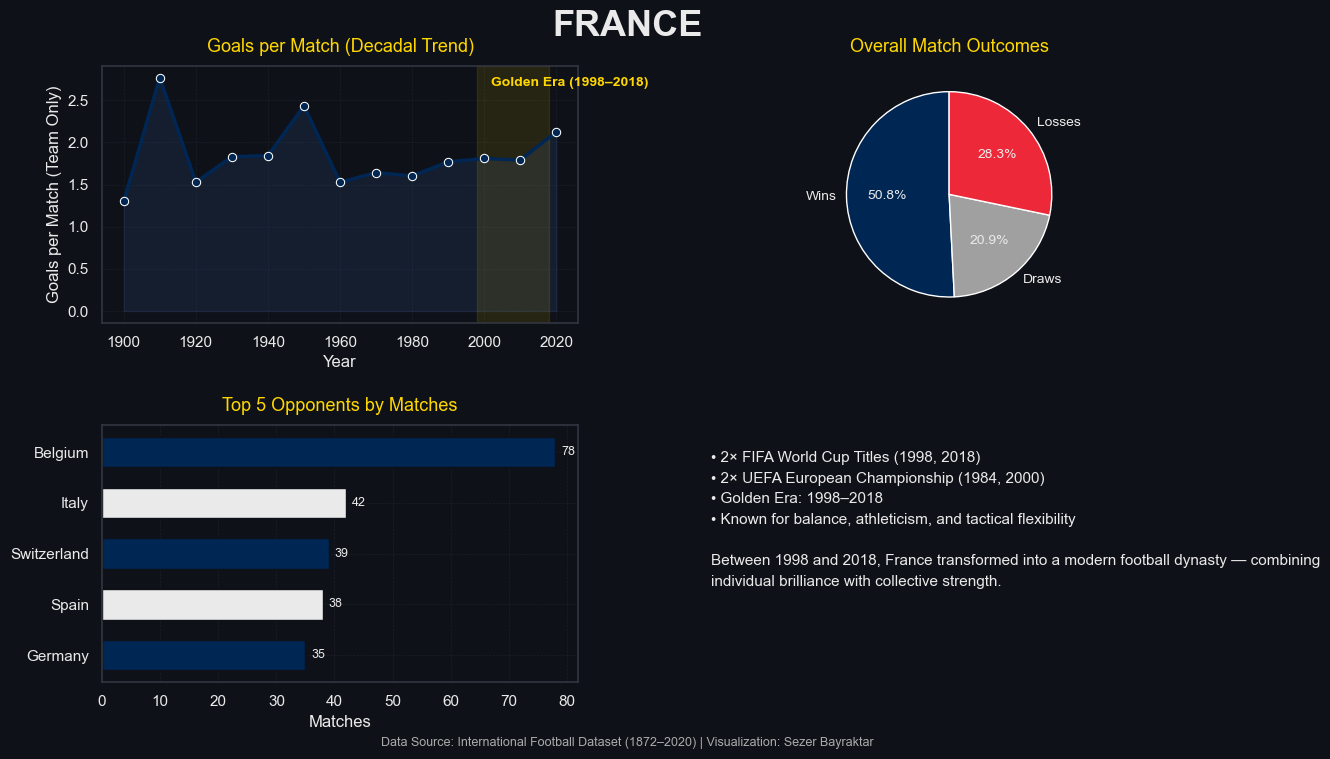

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors

def get_country_data(df, country, alt_names=None):
    if alt_names is None:
        alt_names = []
    all_names = [country] + alt_names
    df_country = df[
        (df['home_team'].isin(all_names)) | (df['away_team'].isin(all_names))
    ].copy()
    df_country['Opponent'] = df_country.apply(
        lambda x: x['away_team'] if x['home_team'] in all_names else x['home_team'], axis=1
    )
    top_opponents = (
        df_country['Opponent']
        .value_counts()
        .head(5)
        .reset_index()
    )
    top_opponents.columns = ['Opponent', 'Matches']
    return df_country, top_opponents, all_names

plt.style.use("dark_background")
background = "#0e1117"
blue = "#002654"
light_blue = "#355C9C"
white = "#EAEAEA"
gray = "#A0A0A0"
gray_light = "#D9D9D9"
dark_gray = "#505050"
red = "#ED2939"
accent = "#FFD700"
grid = "#30343F"
text = "#EAEAEA"

sns.set(rc={
    'axes.facecolor': background,
    'figure.facecolor': background,
    'axes.edgecolor': grid,
    'axes.labelcolor': text,
    'text.color': text,
    'xtick.color': text,
    'ytick.color': text,
    'grid.color': grid,
    'axes.titlesize': 13,
    'axes.titlecolor': accent
})

country = "France"
df_fra, top_opponents, all_names = get_country_data(df, country)

df_fra['team_goals'] = df_fra.apply(
    lambda x: x['home_score'] if x['home_team'] in all_names else x['away_score'],
    axis=1
)

goals_trend = (
    df_fra.groupby('decade')['team_goals']
    .mean()
    .reset_index()
    .rename(columns={'team_goals': 'Goals_per_Match'})
)

total_matches = len(df_fra)
wins = ((df_fra['home_team'].isin(all_names)) & df_fra['is_home_win']).sum() + \
       ((df_fra['away_team'].isin(all_names)) & df_fra['is_away_win']).sum()
draws = df_fra['is_draw'].sum()
losses = total_matches - wins - draws

fig = plt.figure(figsize=(14, 8), facecolor=background)
fig.suptitle("FRANCE", fontsize=26, color=white, fontweight="bold", y=0.95)
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])
sns.lineplot(data=goals_trend, x='decade', y='Goals_per_Match',
             color=blue, marker='o', linewidth=2.5, ax=ax1)
ax1.fill_between(goals_trend['decade'], goals_trend['Goals_per_Match'],
                 color=light_blue, alpha=0.18)
ax1.set_title("Goals per Match (Decadal Trend)", pad=10)
ax1.set_ylabel("Goals per Match (Team Only)")
ax1.set_xlabel("Year")
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
ax1.axvspan(1998, 2018, color=accent, alpha=0.10)
ax1.text(2002, goals_trend['Goals_per_Match'].max() - 0.1,
         "Golden Era (1998–2018)", color=accent, fontsize=10, fontweight="bold")

ax2 = fig.add_subplot(gs[0, 1])
colors = [blue, gray, red]
wedges, texts_, autotexts = ax2.pie(
    [wins, draws, losses],
    labels=['Wins', 'Draws', 'Losses'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)
for w, a in zip(wedges, autotexts):
    r, g, b, *_ = w.get_facecolor()
    brightness = (r + g + b) / 3
    a.set_color(dark_gray if brightness > 0.7 else white)
ax2.set_title("Overall Match Outcomes", pad=10, color=accent)

ax3 = fig.add_subplot(gs[1, 0])
ax3.set_title("Top 5 Opponents by Matches", color=accent, pad=10)
ax3.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
bar_colors = [blue if i % 2 == 0 else white for i in range(len(top_opponents))]
for i, (opp, val) in enumerate(zip(top_opponents['Opponent'], top_opponents['Matches'])):
    ax3.barh(i, val, color=bar_colors[i], edgecolor=background, height=0.6)
    ax3.text(val + 1, i, f"{val}", va='center', color=text, fontsize=9)
ax3.set_yticks(range(len(top_opponents)))
ax3.set_yticklabels(top_opponents['Opponent'], color=text)
ax3.set_xlabel("Matches", color=text)
ax3.invert_yaxis()

ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
info = (
    "• 2× FIFA World Cup Titles (1998, 2018)\n"
    "• 2× UEFA European Championship (1984, 2000)\n"
    "• Golden Era: 1998–2018\n"
    "• Known for balance, athleticism, and tactical flexibility\n\n"
    "Between 1998 and 2018, France transformed into a modern football dynasty — "
    "combining individual brilliance with collective strength."
)
ax4.text(0, 0.9, info, color=text, fontsize=11,
         va='top', ha='left', wrap=True, linespacing=1.6)

fig.text(
    0.5, 0.03,
    "Data Source: International Football Dataset (1872–2020) | Visualization: Sezer Bayraktar",
    ha='center', color='#AAAAAA', fontsize=9
)
fig.savefig("france.png", dpi=400, bbox_inches='tight', facecolor=background)
plt.show()

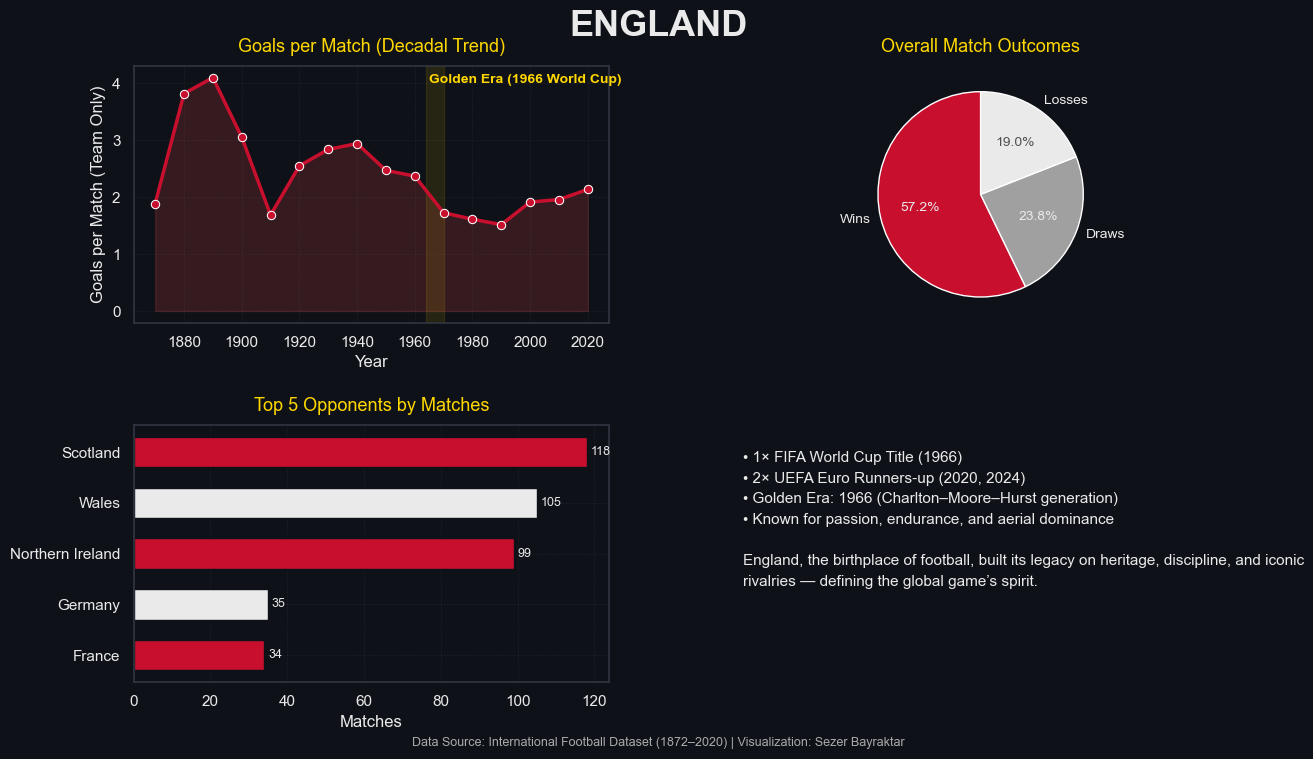

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors

def get_country_data(df, country, alt_names=None):
    if alt_names is None:
        alt_names = []
    all_names = [country] + alt_names
    df_country = df[
        (df['home_team'].isin(all_names)) | (df['away_team'].isin(all_names))
    ].copy()
    df_country['Opponent'] = df_country.apply(
        lambda x: x['away_team'] if x['home_team'] in all_names else x['home_team'], axis=1
    )
    top_opponents = (
        df_country['Opponent']
        .value_counts()
        .head(5)
        .reset_index()
    )
    top_opponents.columns = ['Opponent', 'Matches']
    return df_country, top_opponents, all_names

plt.style.use("dark_background")
background = "#0e1117"
white = "#EAEAEA"
gray = "#A0A0A0"
gray_light = "#D9D9D9"
dark_gray = "#505050"
red = "#C8102E"
light_red = "#E94B4B"
accent = "#FFD700"
text = "#EAEAEA"
grid = "#30343F"

sns.set(rc={
    'axes.facecolor': background,
    'figure.facecolor': background,
    'axes.edgecolor': grid,
    'axes.labelcolor': text,
    'text.color': text,
    'xtick.color': text,
    'ytick.color': text,
    'grid.color': grid,
    'axes.titlesize': 13,
    'axes.titlecolor': accent
})

country = "England"
df_eng, top_opponents, all_names = get_country_data(df, country)

df_eng['team_goals'] = df_eng.apply(
    lambda x: x['home_score'] if x['home_team'] in all_names else x['away_score'],
    axis=1
)

goals_trend = (
    df_eng.groupby('decade')['team_goals']
    .mean()
    .reset_index()
    .rename(columns={'team_goals': 'Goals_per_Match'})
)

total_matches = len(df_eng)
wins = ((df_eng['home_team'].isin(all_names)) & df_eng['is_home_win']).sum() + \
       ((df_eng['away_team'].isin(all_names)) & df_eng['is_away_win']).sum()
draws = df_eng['is_draw'].sum()
losses = total_matches - wins - draws

fig = plt.figure(figsize=(14, 8), facecolor=background)
fig.suptitle("ENGLAND", fontsize=26, color=white, fontweight="bold", y=0.95)
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])
sns.lineplot(data=goals_trend, x='decade', y='Goals_per_Match',
             color=red, marker='o', linewidth=2.5, ax=ax1)
ax1.fill_between(goals_trend['decade'], goals_trend['Goals_per_Match'],
                 color=light_red, alpha=0.18)
ax1.set_title("Goals per Match (Decadal Trend)", pad=10)
ax1.set_ylabel("Goals per Match (Team Only)")
ax1.set_xlabel("Year")
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
ax1.axvspan(1964, 1970, color=accent, alpha=0.10)
ax1.text(1965, goals_trend['Goals_per_Match'].max() - 0.1,
         "Golden Era (1966 World Cup)", color=accent, fontsize=10, fontweight="bold")

ax2 = fig.add_subplot(gs[0, 1])
colors = [red, gray, white]
wedges, texts_, autotexts = ax2.pie(
    [wins, draws, losses],
    labels=['Wins', 'Draws', 'Losses'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)
for w, a in zip(wedges, autotexts):
    r, g, b, *_ = w.get_facecolor()
    brightness = (r + g + b) / 3
    a.set_color(dark_gray if brightness > 0.7 else white)
ax2.set_title("Overall Match Outcomes", pad=10, color=accent)

ax3 = fig.add_subplot(gs[1, 0])
ax3.set_title("Top 5 Opponents by Matches", color=accent, pad=10)
ax3.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
bar_colors = [red if i % 2 == 0 else white for i in range(len(top_opponents))]
for i, (opp, val) in enumerate(zip(top_opponents['Opponent'], top_opponents['Matches'])):
    ax3.barh(i, val, color=bar_colors[i], edgecolor=background, height=0.6)
    ax3.text(val + 1, i, f"{val}", va='center', color=text, fontsize=9)
ax3.set_yticks(range(len(top_opponents)))
ax3.set_yticklabels(top_opponents['Opponent'], color=text)
ax3.set_xlabel("Matches", color=text)
ax3.invert_yaxis()

ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
info = (
    "• 1× FIFA World Cup Title (1966)\n"
    "• 2× UEFA Euro Runners-up (2020, 2024)\n"
    "• Golden Era: 1966 (Charlton–Moore–Hurst generation)\n"
    "• Known for passion, endurance, and aerial dominance\n\n"
    "England, the birthplace of football, built its legacy on heritage, "
    "discipline, and iconic rivalries — defining the global game’s spirit."
)
ax4.text(0, 0.9, info, color=text, fontsize=11,
         va='top', ha='left', wrap=True, linespacing=1.6)

fig.text(
    0.5, 0.03,
    "Data Source: International Football Dataset (1872–2020) | Visualization: Sezer Bayraktar",
    ha='center', color='#AAAAAA', fontsize=9
)
fig.savefig("england.png", dpi=400, bbox_inches='tight', facecolor=background)
plt.show()

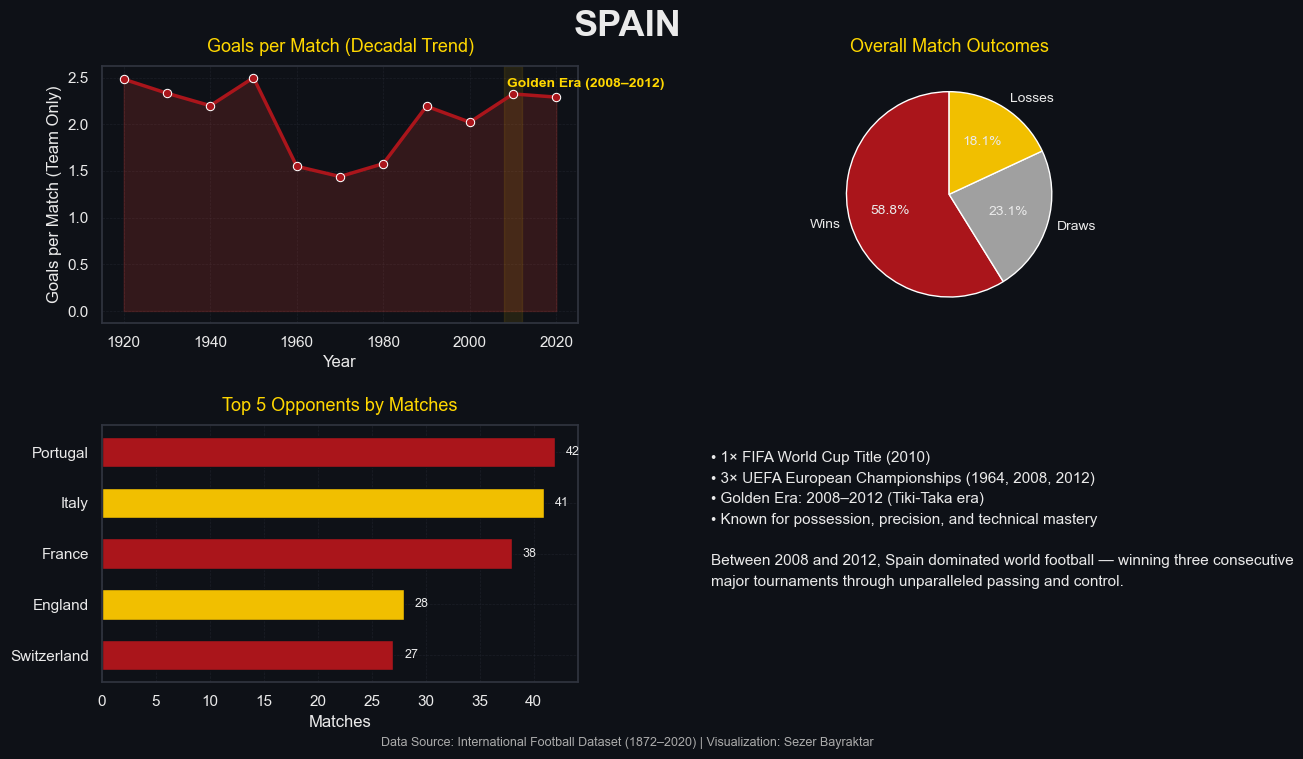

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors

def get_country_data(df, country, alt_names=None):
    if alt_names is None:
        alt_names = []
    all_names = [country] + alt_names
    df_country = df[
        (df['home_team'].isin(all_names)) | (df['away_team'].isin(all_names))
    ].copy()
    df_country['Opponent'] = df_country.apply(
        lambda x: x['away_team'] if x['home_team'] in all_names else x['home_team'], axis=1
    )
    top_opponents = (
        df_country['Opponent']
        .value_counts()
        .head(5)
        .reset_index()
    )
    top_opponents.columns = ['Opponent', 'Matches']
    return df_country, top_opponents, all_names

plt.style.use("dark_background")
background = "#0e1117"
red = "#AA151B"
light_red = "#E03C31"
yellow = "#F1BF00"
gold = "#FFD700"
white = "#EAEAEA"
gray = "#A0A0A0"
gray_light = "#D9D9D9"
dark_gray = "#505050"
grid = "#30343F"
text = "#EAEAEA"

sns.set(rc={
    'axes.facecolor': background,
    'figure.facecolor': background,
    'axes.edgecolor': grid,
    'axes.labelcolor': text,
    'text.color': text,
    'xtick.color': text,
    'ytick.color': text,
    'grid.color': grid,
    'axes.titlesize': 13,
    'axes.titlecolor': gold
})

country = "Spain"
df_esp, top_opponents, all_names = get_country_data(df, country)

df_esp['team_goals'] = df_esp.apply(
    lambda x: x['home_score'] if x['home_team'] in all_names else x['away_score'],
    axis=1
)

goals_trend = (
    df_esp.groupby('decade')['team_goals']
    .mean()
    .reset_index()
    .rename(columns={'team_goals': 'Goals_per_Match'})
)

total_matches = len(df_esp)
wins = ((df_esp['home_team'].isin(all_names)) & df_esp['is_home_win']).sum() + \
       ((df_esp['away_team'].isin(all_names)) & df_esp['is_away_win']).sum()
draws = df_esp['is_draw'].sum()
losses = total_matches - wins - draws

fig = plt.figure(figsize=(14, 8), facecolor=background)
fig.suptitle("SPAIN", fontsize=26, color=white, fontweight="bold", y=0.95)
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])
sns.lineplot(data=goals_trend, x='decade', y='Goals_per_Match',
             color=red, marker='o', linewidth=2.5, ax=ax1)
ax1.fill_between(goals_trend['decade'], goals_trend['Goals_per_Match'],
                 color=light_red, alpha=0.18)
ax1.set_title("Goals per Match (Decadal Trend)", pad=10)
ax1.set_ylabel("Goals per Match (Team Only)")
ax1.set_xlabel("Year")
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
ax1.axvspan(2008, 2012, color=yellow, alpha=0.10)
ax1.text(2008.5, goals_trend['Goals_per_Match'].max() - 0.1,
         "Golden Era (2008–2012)", color=gold, fontsize=10, fontweight="bold")

ax2 = fig.add_subplot(gs[0, 1])
colors = [red, gray, yellow]
wedges, texts_, autotexts = ax2.pie(
    [wins, draws, losses],
    labels=['Wins', 'Draws', 'Losses'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)
for w, a in zip(wedges, autotexts):
    r, g, b, *_ = w.get_facecolor()
    brightness = (r + g + b) / 3
    a.set_color(dark_gray if brightness > 0.7 else white)
ax2.set_title("Overall Match Outcomes", pad=10, color=gold)

ax3 = fig.add_subplot(gs[1, 0])
ax3.set_title("Top 5 Opponents by Matches", color=gold, pad=10)
ax3.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
bar_colors = [red if i % 2 == 0 else yellow for i in range(len(top_opponents))]
for i, (opp, val) in enumerate(zip(top_opponents['Opponent'], top_opponents['Matches'])):
    ax3.barh(i, val, color=bar_colors[i], edgecolor=background, height=0.6)
    ax3.text(val + 1, i, f"{val}", va='center', color=text, fontsize=9)
ax3.set_yticks(range(len(top_opponents)))
ax3.set_yticklabels(top_opponents['Opponent'], color=text)
ax3.set_xlabel("Matches", color=text)
ax3.invert_yaxis()

ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
info = (
    "• 1× FIFA World Cup Title (2010)\n"
    "• 3× UEFA European Championships (1964, 2008, 2012)\n"
    "• Golden Era: 2008–2012 (Tiki-Taka era)\n"
    "• Known for possession, precision, and technical mastery\n\n"
    "Between 2008 and 2012, Spain dominated world football — "
    "winning three consecutive major tournaments through "
    "unparalleled passing and control."
)
ax4.text(0, 0.9, info, color=text, fontsize=11,
         va='top', ha='left', wrap=True, linespacing=1.6)

fig.text(
    0.5, 0.03,
    "Data Source: International Football Dataset (1872–2020) | Visualization: Sezer Bayraktar",
    ha='center', color='#AAAAAA', fontsize=9
)
fig.savefig("spain.png", dpi=400, bbox_inches='tight', facecolor=background)
plt.show()

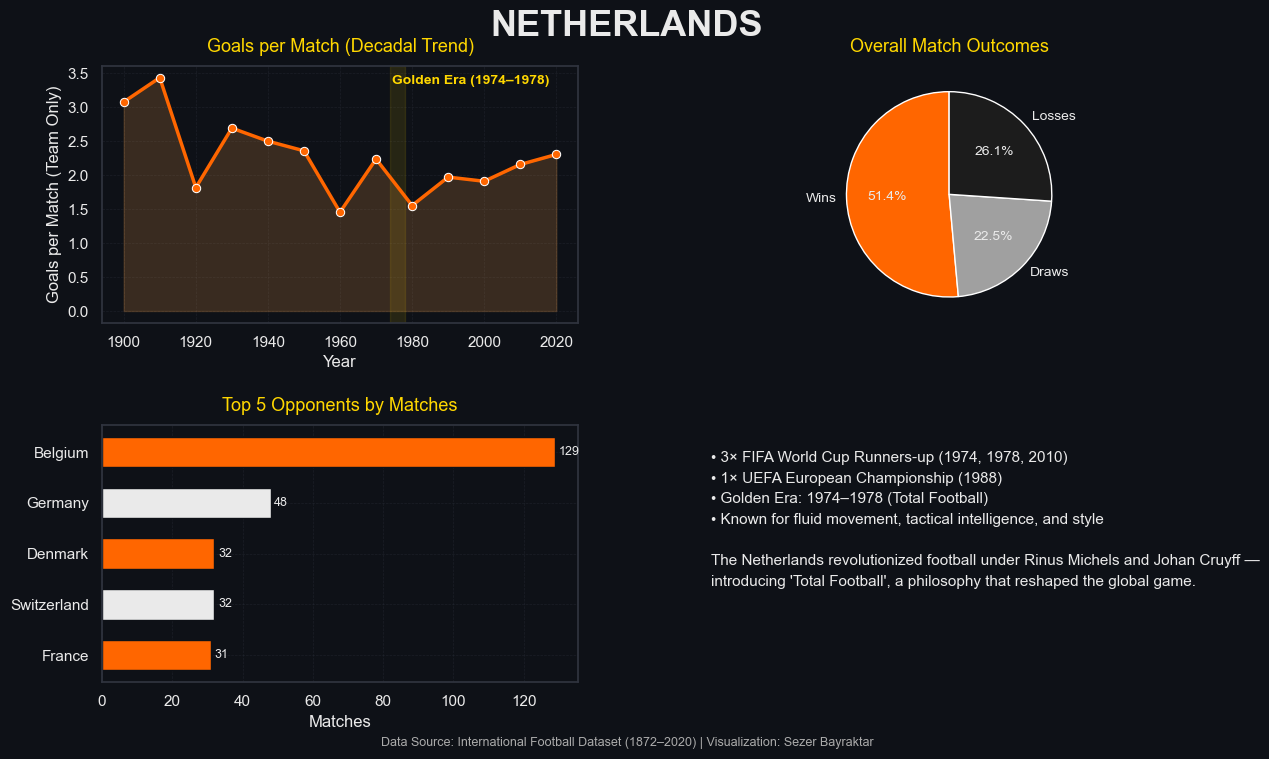

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors

def get_country_data(df, country, alt_names=None):
    if alt_names is None:
        alt_names = []
    all_names = [country] + alt_names
    df_country = df[
        (df['home_team'].isin(all_names)) | (df['away_team'].isin(all_names))
    ].copy()
    df_country['Opponent'] = df_country.apply(
        lambda x: x['away_team'] if x['home_team'] in all_names else x['home_team'], axis=1
    )
    top_opponents = (
        df_country['Opponent']
        .value_counts()
        .head(5)
        .reset_index()
    )
    top_opponents.columns = ['Opponent', 'Matches']
    return df_country, top_opponents, all_names

plt.style.use("dark_background")
background = "#0e1117"
orange = "#FF6600"
orange_light = "#FFA64D"
white = "#EAEAEA"
gray = "#A0A0A0"
gray_light = "#D9D9D9"
dark_gray = "#505050"
black = "#1C1C1C"
accent = "#FFD700"
grid = "#30343F"
text = "#EAEAEA"

sns.set(rc={
    'axes.facecolor': background,
    'figure.facecolor': background,
    'axes.edgecolor': grid,
    'axes.labelcolor': text,
    'text.color': text,
    'xtick.color': text,
    'ytick.color': text,
    'grid.color': grid,
    'axes.titlesize': 13,
    'axes.titlecolor': accent
})

country = "Netherlands"
df_ned, top_opponents, all_names = get_country_data(df, country)

df_ned['team_goals'] = df_ned.apply(
    lambda x: x['home_score'] if x['home_team'] in all_names else x['away_score'],
    axis=1
)

goals_trend = (
    df_ned.groupby('decade')['team_goals']
    .mean()
    .reset_index()
    .rename(columns={'team_goals': 'Goals_per_Match'})
)

total_matches = len(df_ned)
wins = ((df_ned['home_team'].isin(all_names)) & df_ned['is_home_win']).sum() + \
       ((df_ned['away_team'].isin(all_names)) & df_ned['is_away_win']).sum()
draws = df_ned['is_draw'].sum()
losses = total_matches - wins - draws

fig = plt.figure(figsize=(14, 8), facecolor=background)
fig.suptitle("NETHERLANDS", fontsize=26, color=white, fontweight="bold", y=0.95)
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])
sns.lineplot(data=goals_trend, x='decade', y='Goals_per_Match',
             color=orange, marker='o', linewidth=2.5, ax=ax1)
ax1.fill_between(goals_trend['decade'], goals_trend['Goals_per_Match'],
                 color=orange_light, alpha=0.18)
ax1.set_title("Goals per Match (Decadal Trend)", pad=10)
ax1.set_ylabel("Goals per Match (Team Only)")
ax1.set_xlabel("Year")
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
ax1.axvspan(1974, 1978, color=accent, alpha=0.10)
ax1.text(1974.5, goals_trend['Goals_per_Match'].max() - 0.1,
         "Golden Era (1974–1978)", color=accent, fontsize=10, fontweight="bold")

ax2 = fig.add_subplot(gs[0, 1])
colors = [orange, gray, black]
wedges, texts_, autotexts = ax2.pie(
    [wins, draws, losses],
    labels=['Wins', 'Draws', 'Losses'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)
for w, a in zip(wedges, autotexts):
    r, g, b, *_ = w.get_facecolor()
    brightness = (r + g + b) / 3
    a.set_color(dark_gray if brightness > 0.7 else white)
ax2.set_title("Overall Match Outcomes", pad=10, color=accent)

ax3 = fig.add_subplot(gs[1, 0])
ax3.set_title("Top 5 Opponents by Matches", color=accent, pad=10)
ax3.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
bar_colors = [orange if i % 2 == 0 else white for i in range(len(top_opponents))]
for i, (opp, val) in enumerate(zip(top_opponents['Opponent'], top_opponents['Matches'])):
    ax3.barh(i, val, color=bar_colors[i], edgecolor=background, height=0.6)
    ax3.text(val + 1, i, f"{val}", va='center', color=text, fontsize=9)
ax3.set_yticks(range(len(top_opponents)))
ax3.set_yticklabels(top_opponents['Opponent'], color=text)
ax3.set_xlabel("Matches", color=text)
ax3.invert_yaxis()

ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
info = (
    "• 3× FIFA World Cup Runners-up (1974, 1978, 2010)\n"
    "• 1× UEFA European Championship (1988)\n"
    "• Golden Era: 1974–1978 (Total Football)\n"
    "• Known for fluid movement, tactical intelligence, and style\n\n"
    "The Netherlands revolutionized football under Rinus Michels and Johan Cruyff — "
    "introducing 'Total Football', a philosophy that reshaped the global game."
)
ax4.text(0, 0.9, info, color=text, fontsize=11,
         va='top', ha='left', wrap=True, linespacing=1.6)

fig.text(
    0.5, 0.03,
    "Data Source: International Football Dataset (1872–2020) | Visualization: Sezer Bayraktar",
    ha='center', color='#AAAAAA', fontsize=9
)
fig.savefig("netherlands.png", dpi=400, bbox_inches='tight', facecolor=background)
plt.show()

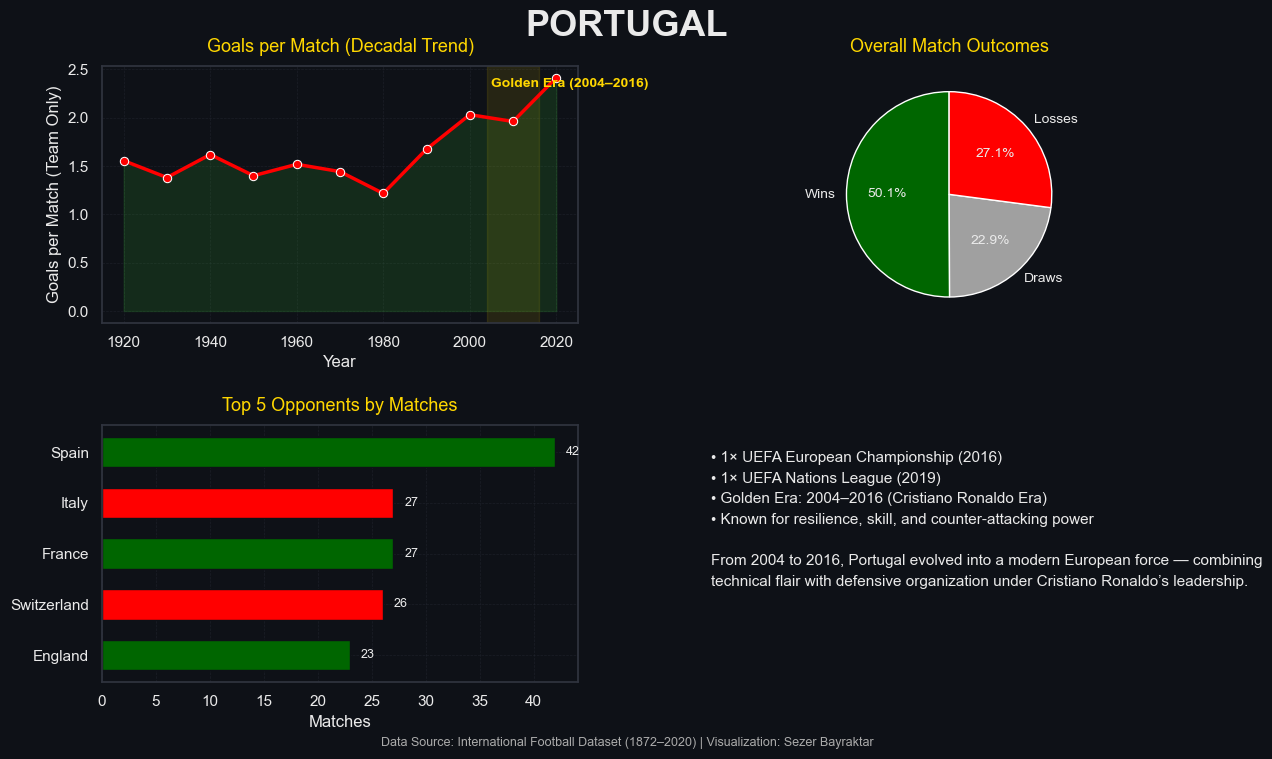

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors

def get_country_data(df, country, alt_names=None):
    """Filters all home & away matches for a given country (and optional alternate names)"""
    if alt_names is None:
        alt_names = []
    all_names = [country] + alt_names
    df_country = df[
        (df['home_team'].isin(all_names)) | (df['away_team'].isin(all_names))
    ].copy()

    df_country['Opponent'] = df_country.apply(
        lambda x: x['away_team'] if x['home_team'] in all_names else x['home_team'], axis=1
    )

    top_opponents = (
        df_country['Opponent']
        .value_counts()
        .head(5)
        .reset_index()
    )
    top_opponents.columns = ['Opponent', 'Matches']
    return df_country, top_opponents, all_names

plt.style.use("dark_background")
background = "#0e1117"
red = "#FF0000"         # Portugal red
dark_red = "#A60000"
green = "#006600"       # Portugal green
light_green = "#33A532"
gold = "#FFD700"
white = "#EAEAEA"
gray = "#A0A0A0"
gray_light = "#D9D9D9"
dark_gray = "#505050"
grid = "#30343F"
text = "#EAEAEA"

sns.set(rc={
    'axes.facecolor': background,
    'figure.facecolor': background,
    'axes.edgecolor': grid,
    'axes.labelcolor': text,
    'text.color': text,
    'xtick.color': text,
    'ytick.color': text,
    'grid.color': grid,
    'axes.titlesize': 13,
    'axes.titlecolor': gold
})

country = "Portugal"
df_por, top_opponents, all_names = get_country_data(df, country)

df_por['team_goals'] = df_por.apply(
    lambda x: x['home_score'] if x['home_team'] in all_names else x['away_score'],
    axis=1
)

goals_trend = (
    df_por.groupby('decade')['team_goals']
    .mean()
    .reset_index()
    .rename(columns={'team_goals': 'Goals_per_Match'})
)

total_matches = len(df_por)
wins = ((df_por['home_team'].isin(all_names)) & df_por['is_home_win']).sum() + \
       ((df_por['away_team'].isin(all_names)) & df_por['is_away_win']).sum()
draws = df_por['is_draw'].sum()
losses = total_matches - wins - draws

fig = plt.figure(figsize=(14, 8), facecolor=background)
fig.suptitle("PORTUGAL", fontsize=26, color=white, fontweight="bold", y=0.95)
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])
sns.lineplot(data=goals_trend, x='decade', y='Goals_per_Match',
             color=red, marker='o', linewidth=2.5, ax=ax1)
ax1.fill_between(goals_trend['decade'], goals_trend['Goals_per_Match'],
                 color=light_green, alpha=0.18)
ax1.set_title("Goals per Match (Decadal Trend)", pad=10)
ax1.set_ylabel("Goals per Match (Team Only)")
ax1.set_xlabel("Year")
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

ax1.axvspan(2004, 2016, color=gold, alpha=0.10)
ax1.text(2005, goals_trend['Goals_per_Match'].max() - 0.1,
         "Golden Era (2004–2016)", color=gold, fontsize=10, fontweight="bold")


ax2 = fig.add_subplot(gs[0, 1])
colors = [green, gray, red]
wedges, texts_, autotexts = ax2.pie(
    [wins, draws, losses],
    labels=['Wins', 'Draws', 'Losses'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)

for w, a in zip(wedges, autotexts):
    r, g, b, *_ = w.get_facecolor()
    brightness = (r + g + b) / 3
    a.set_color(dark_gray if brightness > 0.7 else white)

ax2.set_title("Overall Match Outcomes", pad=10, color=gold)

ax3 = fig.add_subplot(gs[1, 0])
ax3.set_title("Top 5 Opponents by Matches", color=gold, pad=10)
ax3.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

bar_colors = [green if i % 2 == 0 else red for i in range(len(top_opponents))]
for i, (opp, val) in enumerate(zip(top_opponents['Opponent'], top_opponents['Matches'])):
    ax3.barh(i, val, color=bar_colors[i], edgecolor=background, height=0.6)
    ax3.text(val + 1, i, f"{val}", va='center', color=text, fontsize=9)

ax3.set_yticks(range(len(top_opponents)))
ax3.set_yticklabels(top_opponents['Opponent'], color=text)
ax3.set_xlabel("Matches", color=text)
ax3.invert_yaxis()

ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")

info = (
    "• 1× UEFA European Championship (2016)\n"
    "• 1× UEFA Nations League (2019)\n"
    "• Golden Era: 2004–2016 (Cristiano Ronaldo Era)\n"
    "• Known for resilience, skill, and counter-attacking power\n\n"
    "From 2004 to 2016, Portugal evolved into a modern European force — "
    "combining technical flair with defensive organization under Cristiano Ronaldo’s leadership."
)
ax4.text(0, 0.9, info, color=text, fontsize=11,
         va='top', ha='left', wrap=True, linespacing=1.6)

fig.text(
    0.5, 0.03,
    "Data Source: International Football Dataset (1872–2020) | Visualization: Sezer Bayraktar",
    ha='center', color='#AAAAAA', fontsize=9
)
fig.savefig("portugal.png", dpi=400, bbox_inches='tight', facecolor=background)
plt.show()

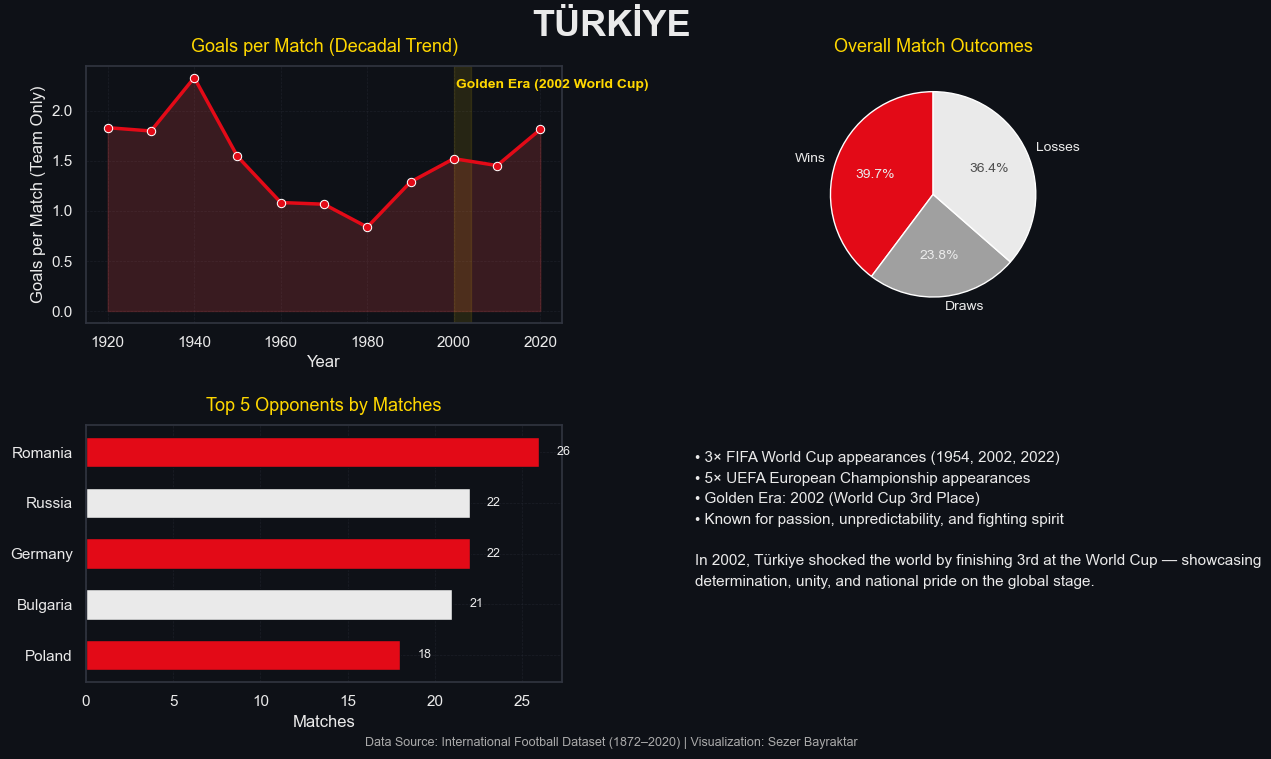

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors

def get_country_data(df, dataset_name, display_name):
    """Filters all home & away matches for the given dataset name ('Turkey')"""
    all_names = [dataset_name]
    df_country = df[
        (df['home_team'].isin(all_names)) | (df['away_team'].isin(all_names))
    ].copy()

    df_country['Opponent'] = df_country.apply(
        lambda x: x['away_team'] if x['home_team'] in all_names else x['home_team'], axis=1
    )

    top_opponents = (
        df_country['Opponent']
        .value_counts()
        .head(5)
        .reset_index()
    )
    top_opponents.columns = ['Opponent', 'Matches']
    return df_country, top_opponents, all_names, display_name

plt.style.use("dark_background")
background = "#0e1117"
red = "#E30A17"        # Turkish red
light_red = "#FF4C4C"  # lighter red fill
white = "#EAEAEA"
gray = "#A0A0A0"
gray_light = "#D9D9D9"
dark_gray = "#505050"
accent = "#FFD700"      # gold for highlights
grid = "#30343F"
text = "#EAEAEA"

sns.set(rc={
    'axes.facecolor': background,
    'figure.facecolor': background,
    'axes.edgecolor': grid,
    'axes.labelcolor': text,
    'text.color': text,
    'xtick.color': text,
    'ytick.color': text,
    'grid.color': grid,
    'axes.titlesize': 13,
    'axes.titlecolor': accent
})

dataset_name = "Turkey"
display_name = "TÜRKİYE"
df_tur, top_opponents, all_names, display_name = get_country_data(df, dataset_name, display_name)

df_tur['team_goals'] = df_tur.apply(
    lambda x: x['home_score'] if x['home_team'] in all_names else x['away_score'],
    axis=1
)

goals_trend = (
    df_tur.groupby('decade')['team_goals']
    .mean()
    .reset_index()
    .rename(columns={'team_goals': 'Goals_per_Match'})
)

total_matches = len(df_tur)
wins = ((df_tur['home_team'].isin(all_names)) & df_tur['is_home_win']).sum() + \
       ((df_tur['away_team'].isin(all_names)) & df_tur['is_away_win']).sum()
draws = df_tur['is_draw'].sum()
losses = total_matches - wins - draws

fig = plt.figure(figsize=(14, 8), facecolor=background)
fig.suptitle(display_name, fontsize=26, color=white, fontweight="bold", y=0.95)
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])
sns.lineplot(data=goals_trend, x='decade', y='Goals_per_Match',
             color=red, marker='o', linewidth=2.5, ax=ax1)
ax1.fill_between(goals_trend['decade'], goals_trend['Goals_per_Match'],
                 color=light_red, alpha=0.18)
ax1.set_title("Goals per Match (Decadal Trend)", pad=10)
ax1.set_ylabel("Goals per Match (Team Only)")
ax1.set_xlabel("Year")
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

ax1.axvspan(2000, 2004, color=accent, alpha=0.10)
ax1.text(2000.5, goals_trend['Goals_per_Match'].max() - 0.1,
         "Golden Era (2002 World Cup)", color=accent, fontsize=10, fontweight="bold")

ax2 = fig.add_subplot(gs[0, 1])
colors = [red, gray, white]
wedges, texts_, autotexts = ax2.pie(
    [wins, draws, losses],
    labels=['Wins', 'Draws', 'Losses'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)

for w, a in zip(wedges, autotexts):
    r, g, b, *_ = w.get_facecolor()
    brightness = (r + g + b) / 3
    a.set_color(dark_gray if brightness > 0.7 else white)

ax2.set_title("Overall Match Outcomes", pad=10, color=accent)

ax3 = fig.add_subplot(gs[1, 0])
ax3.set_title("Top 5 Opponents by Matches", color=accent, pad=10)
ax3.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

bar_colors = [red if i % 2 == 0 else white for i in range(len(top_opponents))]
for i, (opp, val) in enumerate(zip(top_opponents['Opponent'], top_opponents['Matches'])):
    ax3.barh(i, val, color=bar_colors[i], edgecolor=background, height=0.6)
    ax3.text(val + 1, i, f"{val}", va='center', color=text, fontsize=9)

ax3.set_yticks(range(len(top_opponents)))
ax3.set_yticklabels(top_opponents['Opponent'], color=text)
ax3.set_xlabel("Matches", color=text)
ax3.invert_yaxis()

ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")

info = (
    "• 3× FIFA World Cup appearances (1954, 2002, 2022)\n"
    "• 5× UEFA European Championship appearances\n"
    "• Golden Era: 2002 (World Cup 3rd Place)\n"
    "• Known for passion, unpredictability, and fighting spirit\n\n"
    "In 2002, Türkiye shocked the world by finishing 3rd at the World Cup — "
    "showcasing determination, unity, and national pride on the global stage."
)
ax4.text(0, 0.9, info, color=text, fontsize=11,
         va='top', ha='left', wrap=True, linespacing=1.6)

fig.text(
    0.5, 0.03,
    "Data Source: International Football Dataset (1872–2020) | Visualization: Sezer Bayraktar",
    ha='center', color='#AAAAAA', fontsize=9
)
fig.savefig("türkiye.png", dpi=400, bbox_inches='tight', facecolor=background)
plt.show()